# Project 2 — Portfolio Optimization
**Group 1: Mario, Elie, Anthony**
**Period:** 2017-01-01 → 2023-12-31 | **Universe:** 20 equities across 7 sectors


In [1]:
%config InlineBackend.figure_format = "retina"
%pip install quantstats


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 6.1 MB/s eta 0:00:00


In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp
import quantstats as qs
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(context="talk", style="whitegrid",
              palette="colorblind", color_codes=True,
              rc={"figure.figsize": [12, 8]})

# Marker cycle for individual-asset scatter plots (20 assets)
MARKERS = ["o", "x", "d", "*", "^", "v", "<", ">", "s", "p",
           "h", "H", "+", "1", "2", "3", "4", "8", "P", "X"]

N_DAYS = 252   # trading days per year


## 1. Asset Selection and Download
Twenty equities across seven sectors, downloaded from Yahoo Finance
for the period **2017-01-01 → 2023-12-31**.


In [3]:
ASSETS = [
    "GS",    "MS",   "SCHW",   # Financials
    "JNJ",   "ABBV", "TMO",    # Healthcare
    "XOM",   "SLB",  "EOG",    # Energy
    "COST",  "NKE",  "SBUX",   # Consumer
    "CAT",   "DE",   "UPS",    # Industrials
    "AMD",   "ORCL", "CRM",    # Technology
    "CMCSA", "LIN",            # Comms / Materials
]

SECTORS = {
    "Financials":  ["GS",   "MS",   "SCHW"],
    "Healthcare":  ["JNJ",  "ABBV", "TMO"],
    "Energy":      ["XOM",  "SLB",  "EOG"],
    "Consumer":    ["COST", "NKE",  "SBUX"],
    "Industrials": ["CAT",  "DE",   "UPS"],
    "Technology":  ["AMD",  "ORCL", "CRM"],
    "Comms/Mat":   ["CMCSA","LIN"],
}

n_assets = len(ASSETS)
print(f"Total assets : {n_assets}")
print(f"Sectors      : {list(SECTORS.keys())}")


Total assets : 20
Sectors      : ['Financials', 'Healthcare', 'Energy', 'Consumer', 'Industrials', 'Technology', 'Comms/Mat']


In [5]:
prices_df = yf.download(ASSETS,
                        start="2017-01-01",
                        end="2023-12-31",
                        auto_adjust=True)["Close"]

prices_df = prices_df[ASSETS]   # enforce column order

print(f"Shape      : {prices_df.shape}")
print(f"Date range : {prices_df.index[0].date()} \u2192 {prices_df.index[-1].date()}")
print(f"\nMissing values per ticker:\n{prices_df.isnull().sum()}")
prices_df.tail(3)


[*********************100%***********************]  20 of 20 completed

Shape      : (1760, 20)
Date range : 2017-01-03 → 2023-12-29

Missing values per ticker:
Ticker
GS       0
MS       0
SCHW     0
JNJ      0
ABBV     0
TMO      0
XOM      0
SLB      0
EOG      0
COST     0
NKE      0
SBUX     0
CAT      0
DE       0
UPS      0
AMD      0
ORCL     0
CRM      0
CMCSA    0
LIN      0
dtype: int64


Ticker,GS,MS,SCHW,JNJ,ABBV,TMO,XOM,SLB,EOG,COST,NKE,SBUX,CAT,DE,UPS,AMD,ORCL,CRM,CMCSA,LIN
Date,,,,,,,,,,,,,,,,,,,,
2023-12-27,367.879,87.425,67.206,147.051,143.218,528.339,94.199,49.846,115.612,658.587,102.906,89.886,288.374,388.911,140.000,146.070,103.356,263.518,38.121,400.857
2023-12-28,369.726,87.406,67.478,147.267,143.098,529.621,92.836,49.103,112.876,654.933,104.529,90.490,287.175,388.027,140.420,148.760,103.659,262.392,38.233,399.454
2023-12-29,369.113,87.042,66.750,147.418,143.301,527.484,92.642,48.915,112.523,651.950,104.289,90.565,286.004,388.620,140.349,147.410,102.859,259.981,37.999,400.370


## 2. Price and Return Plots by Sector


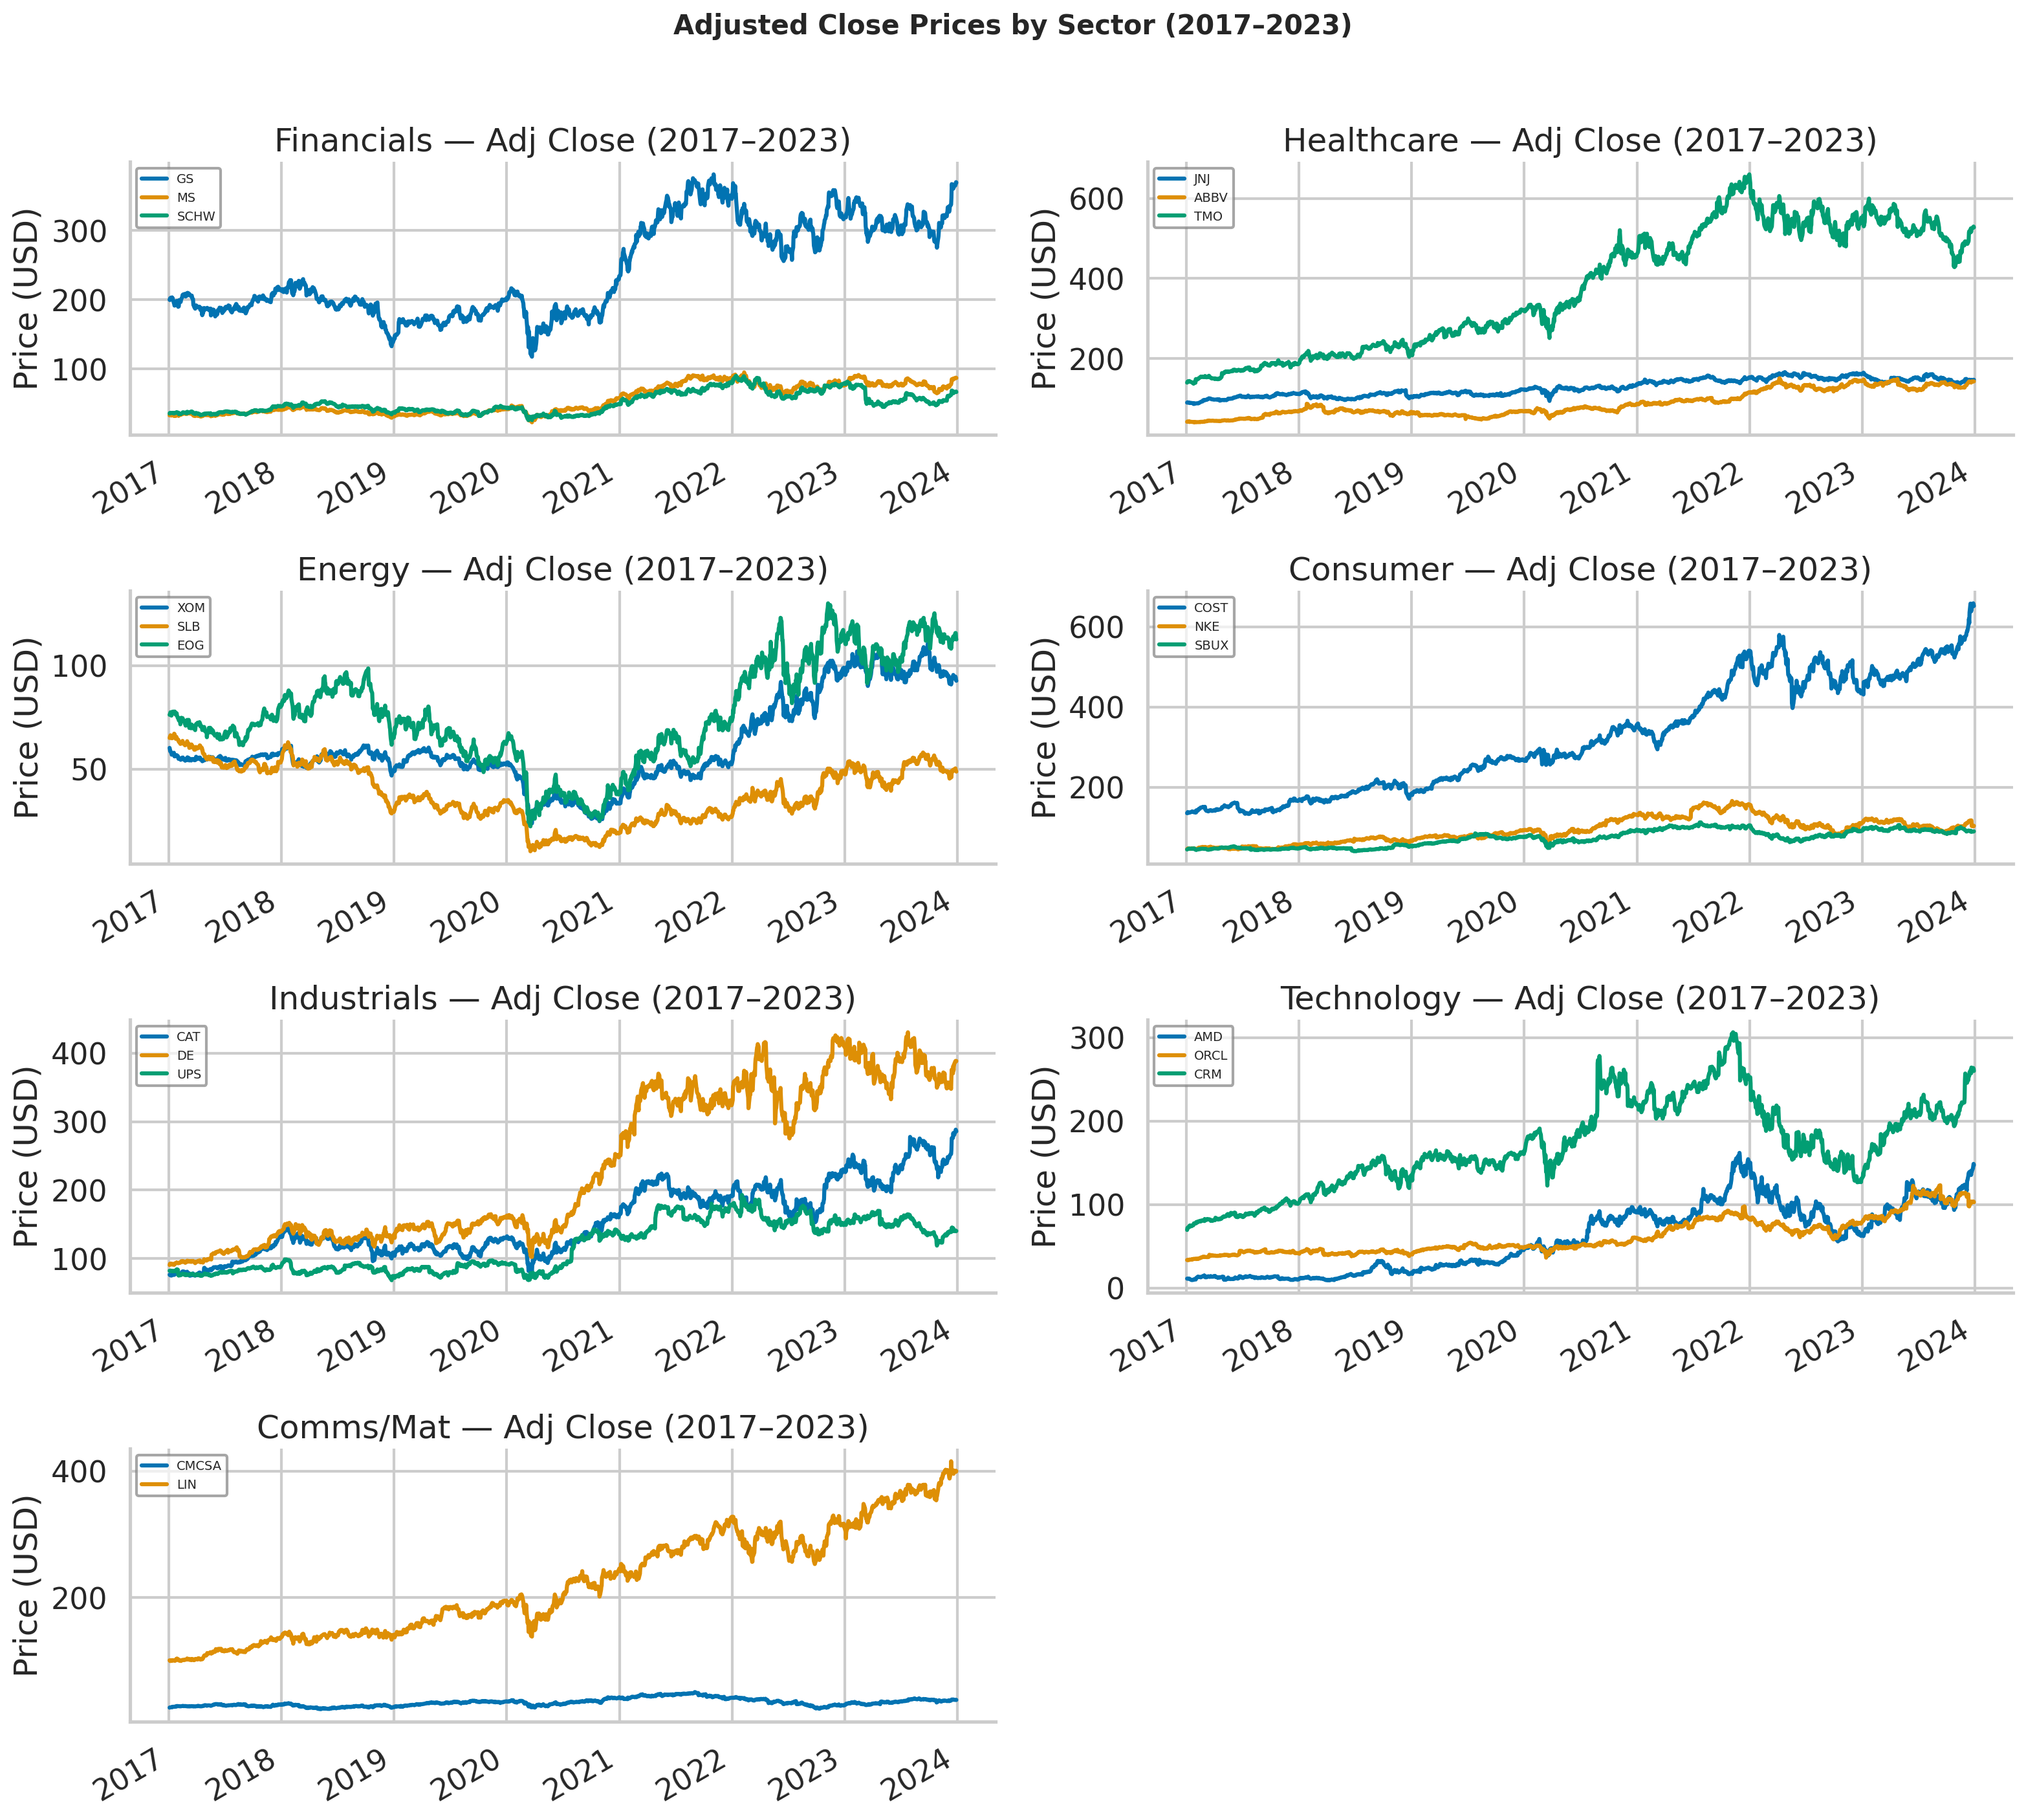

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
for ax, (sector, tkrs) in zip(axes.flat, SECTORS.items()):
    prices_df[tkrs].plot(ax=ax, title=f"{sector} — Adj Close (2017–2023)")
    ax.set_ylabel("Price (USD)")
    ax.set_xlabel("")
    ax.legend(fontsize=7, loc="upper left", framealpha=0.7, edgecolor="gray")
    sns.despine(ax=ax)
axes.flat[-1].set_visible(False)
plt.suptitle("Adjusted Close Prices by Sector (2017–2023)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Sector Price Overview (2017–2023)

**Overall market behavior:** Adjusted closing prices across most sectors show a clear drawdown around early 2020 followed by a broad recovery, indicating exposure to a common market-wide shock.

*   **Financials:** Moderate growth pre-2020 with a visible downturn and subsequent recovery. Noticeable dispersion in price levels across firms suggests heterogeneity within the sector.

*   **Healthcare:** Generally smoother and more consistent upward trends with comparatively lower visible volatility, indicating more defensive characteristics.

*   **Energy:** Displays the highest cyclicality and volatility, with a sharp decline in 2020 followed by a strong rebound, consistent with the sector’s sensitivity to macro conditions.

*   **Consumer:** Shows steady long-term growth for key names with moderate fluctuations, suggesting relatively stable performance compared to more cyclical sectors.

*   **Industrials:** Clear cyclical pattern with a pronounced 2020 dip and strong recovery; differing growth paths across firms indicate imperfect intra-sector correlation.

*   **Technology:** Strong growth through 2021 followed by a noticeable drawdown and partial recovery, reflecting higher volatility and growth sensitivity.



*   **Comms/Materials:** Divergent behavior between the included stocks, indicating weak co-movement and additional diversification potential.

*   **Portfolio implication:** The variation in trends, volatility, and co-movement across the 20 assets supports the presence of diversification opportunities for mean-variance optimization.

In [7]:
# Simple returns
returns_df = prices_df.pct_change().dropna()

print(f"Returns shape : {returns_df.shape}")
returns_df.tail(3)

Returns shape : (1759, 20)


Ticker,GS,MS,SCHW,JNJ,ABBV,TMO,XOM,SLB,EOG,COST,NKE,SBUX,CAT,DE,UPS,AMD,ORCL,CRM,CMCSA,LIN
Date,,,,,,,,,,,,,,,,,,,,
2023-12-27,0.008,0.009,0.005,0.001,0.002,0.004,-0.005,-0.012,-0.000,0.011,-0.008,-0.004,0.008,0.001,-0.008,0.019,-0.002,0.002,0.001,0.003
2023-12-28,0.005,-0.000,0.004,0.001,-0.001,0.002,-0.014,-0.015,-0.024,-0.006,0.016,0.007,-0.004,-0.002,0.003,0.018,0.003,-0.004,0.003,-0.004
2023-12-29,-0.002,-0.004,-0.011,0.001,0.001,-0.004,-0.002,-0.004,-0.003,-0.005,-0.002,0.001,-0.004,0.002,-0.001,-0.009,-0.008,-0.009,-0.006,0.002


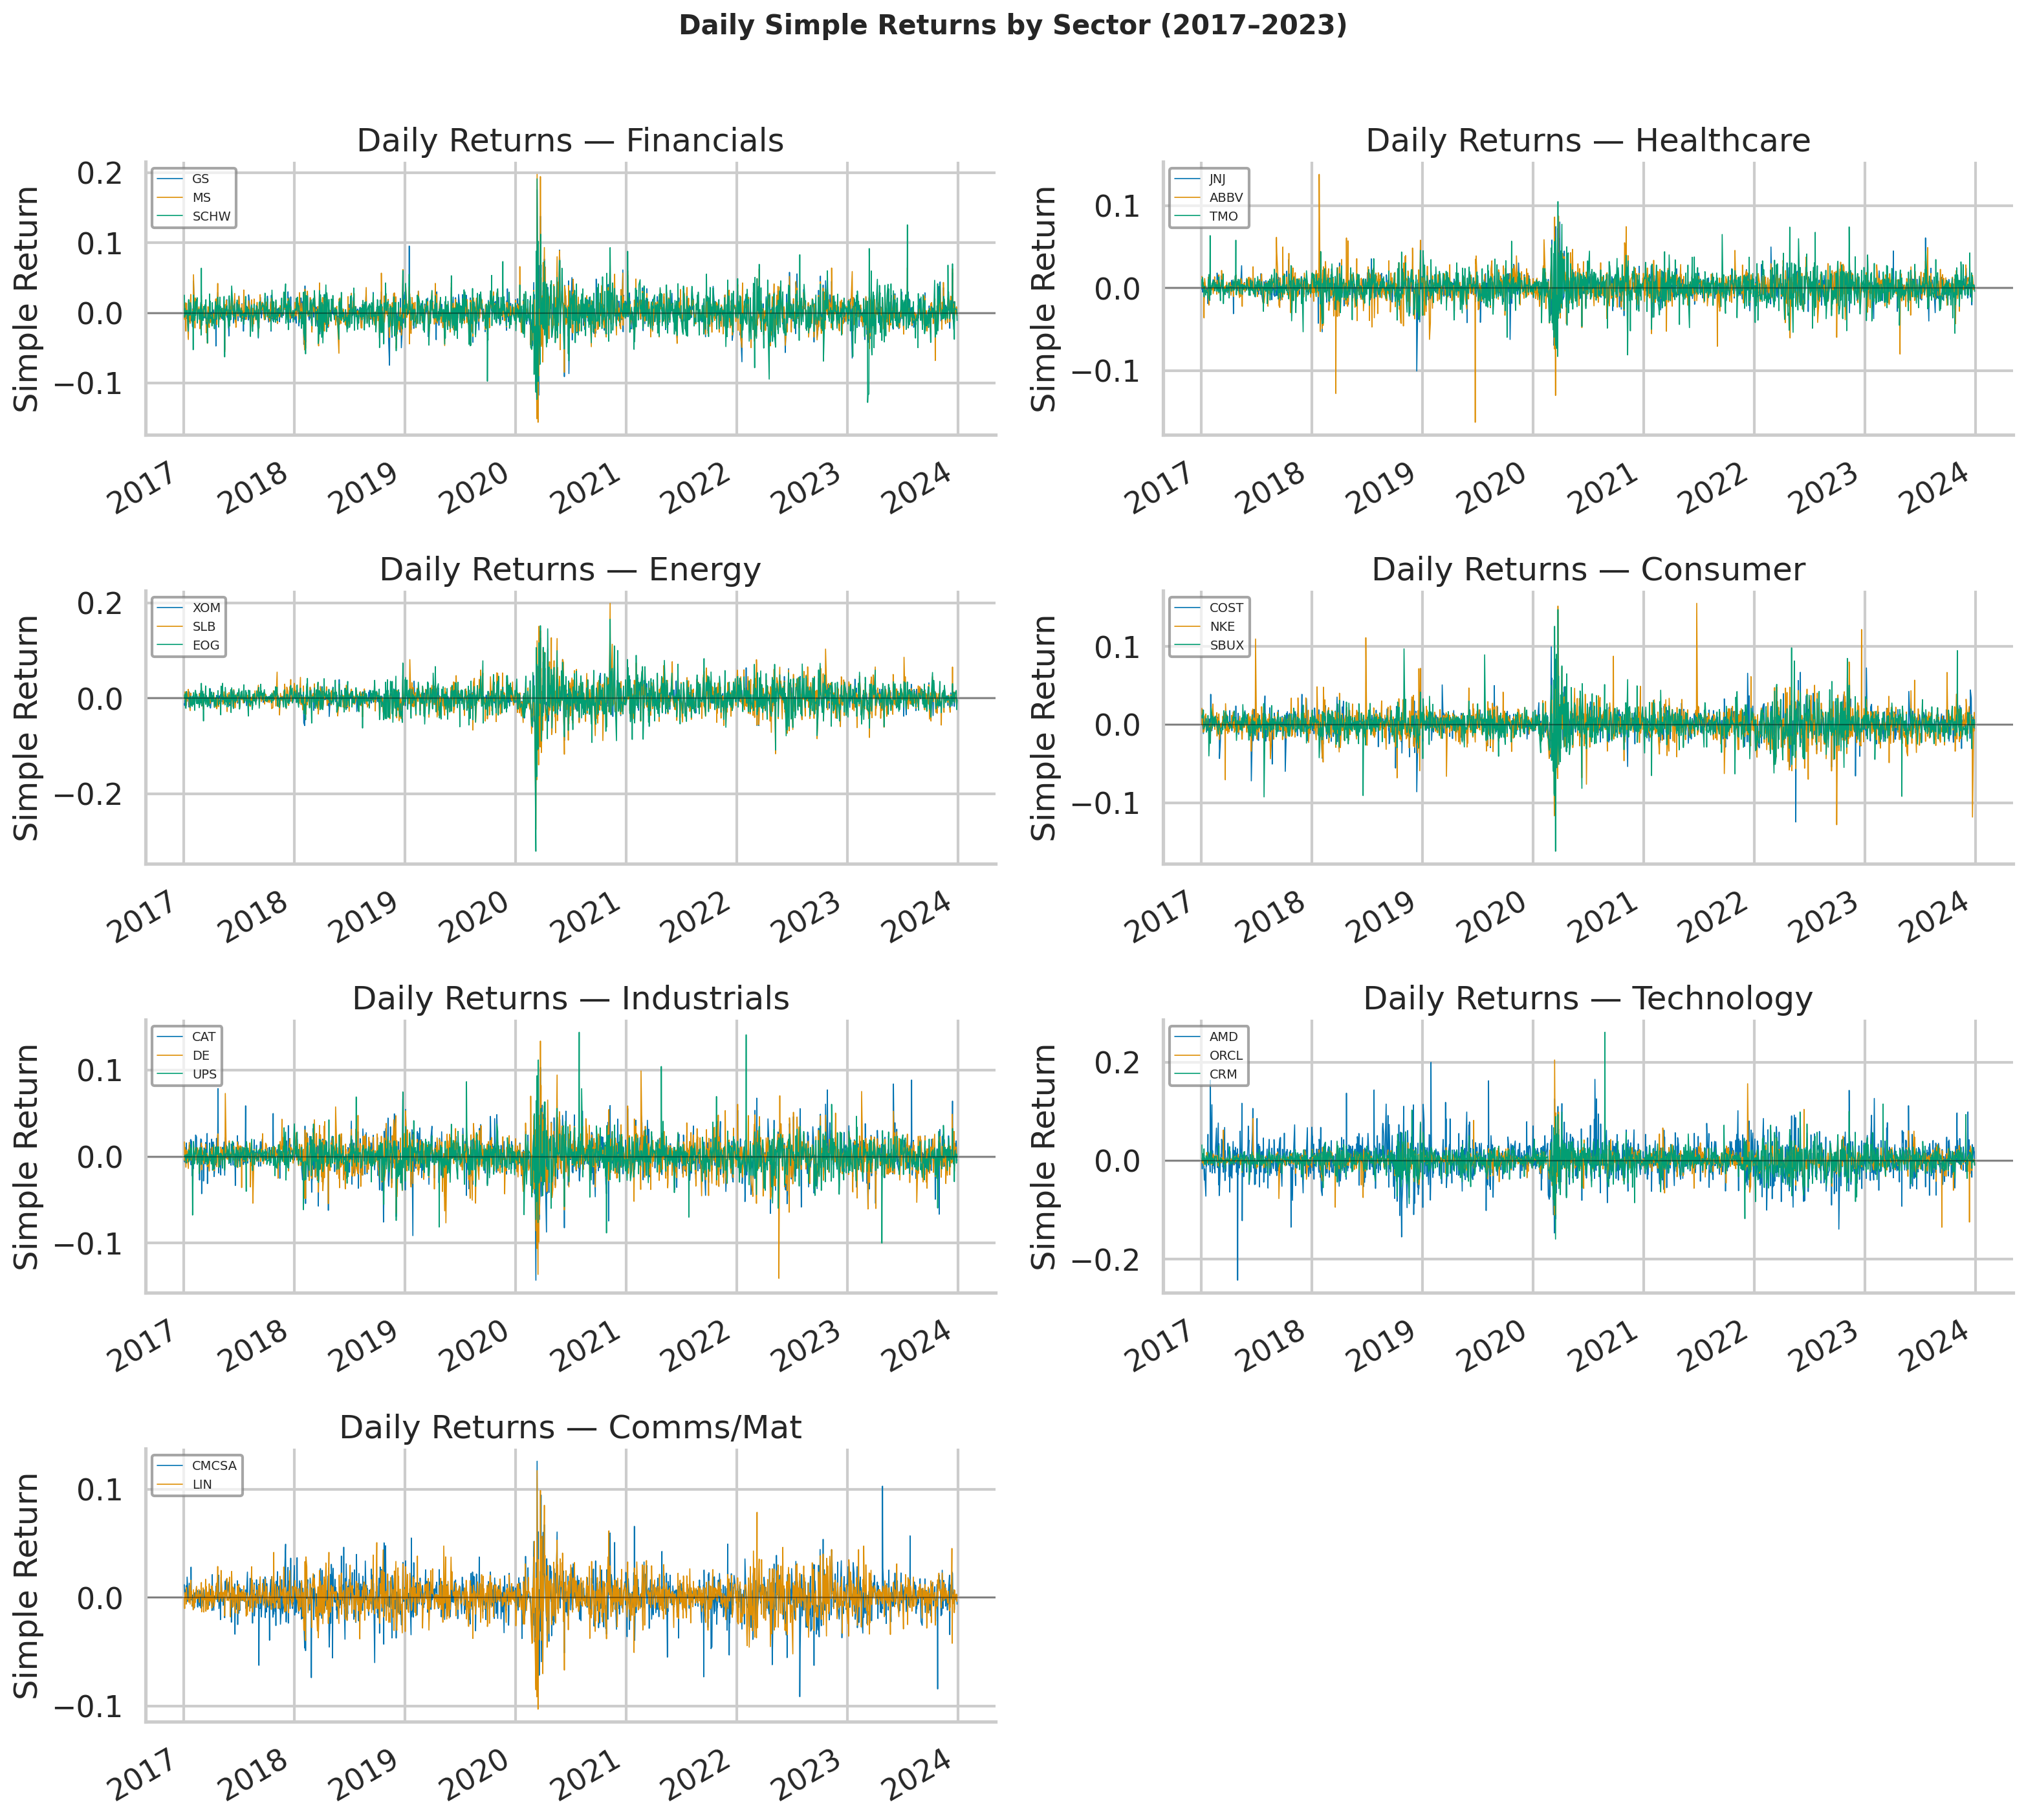

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
for ax, (sector, tkrs) in zip(axes.flat, SECTORS.items()):
    returns_df[tkrs].plot(ax=ax, title=f"Daily Returns — {sector}",
                          linewidth=0.6)
    ax.set_ylabel("Simple Return")
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.4)
    ax.set_xlabel("")
    ax.legend(fontsize=7, loc="upper left", framealpha=0.7, edgecolor="gray")
    sns.despine(ax=ax)
axes.flat[-1].set_visible(False)
plt.suptitle("Daily Simple Returns by Sector (2017–2023)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Observations from the daily simple return plots:

*   Daily returns for all sectors fluctuate around zero, which is expected for short-horizon percentage changes.

*   Energy and Technology stocks show wider and more frequent swings, indicating relatively higher short-term volatility.

*   Healthcare and Consumer names appear more tightly clustered around zero, suggesting comparatively lower day-to-day variability.

*   Financials and Industrials display moderate volatility, sitting between the more stable and more volatile sectors.

*   Overall, return movements are not perfectly synchronized across assets, supporting the presence of diversification potential in portfolio construction.

## 3. 1/N Portfolio — Equal-Weight Baseline
The equally-weighted (1/N) portfolio is the simplest possible allocation.
It serves as a **benchmark**

In [9]:
portfolio_weights = n_assets * [1 / n_assets]

portfolio_returns = pd.Series(
    np.dot(portfolio_weights, returns_df.T),
    index=returns_df.index
)

equity      = (1 + portfolio_returns).cumprod()
running_max = equity.cummax()
drawdown    = equity / running_max - 1

sharpe   = portfolio_returns.mean() / portfolio_returns.std() * np.sqrt(N_DAYS)
ann_ret  = portfolio_returns.mean() * N_DAYS
ann_vol  = portfolio_returns.std()  * np.sqrt(N_DAYS)
max_dd   = drawdown.min()
tot_ret  = equity.iloc[-1] - 1

print("=== 1/N (Equal-Weight) Portfolio — 2017–2023 ===")
print(f"  Annualized Return    : {ann_ret*100:>7.2f}%")
print(f"  Annualized Volatility: {ann_vol*100:>7.2f}%")
print(f"  Sharpe Ratio (Rf=0)  : {sharpe:>7.4f}")
print(f"  Max Drawdown         : {max_dd*100:>7.2f}%")
print(f"  Total Return (7 yr)  : {tot_ret*100:>7.2f}%")


=== 1/N (Equal-Weight) Portfolio — 2017–2023 ===
  Annualized Return    :   18.87%
  Annualized Volatility:   20.72%
  Sharpe Ratio (Rf=0)  :  0.9109
  Max Drawdown         :  -35.54%
  Total Return (7 yr)  :  221.11%


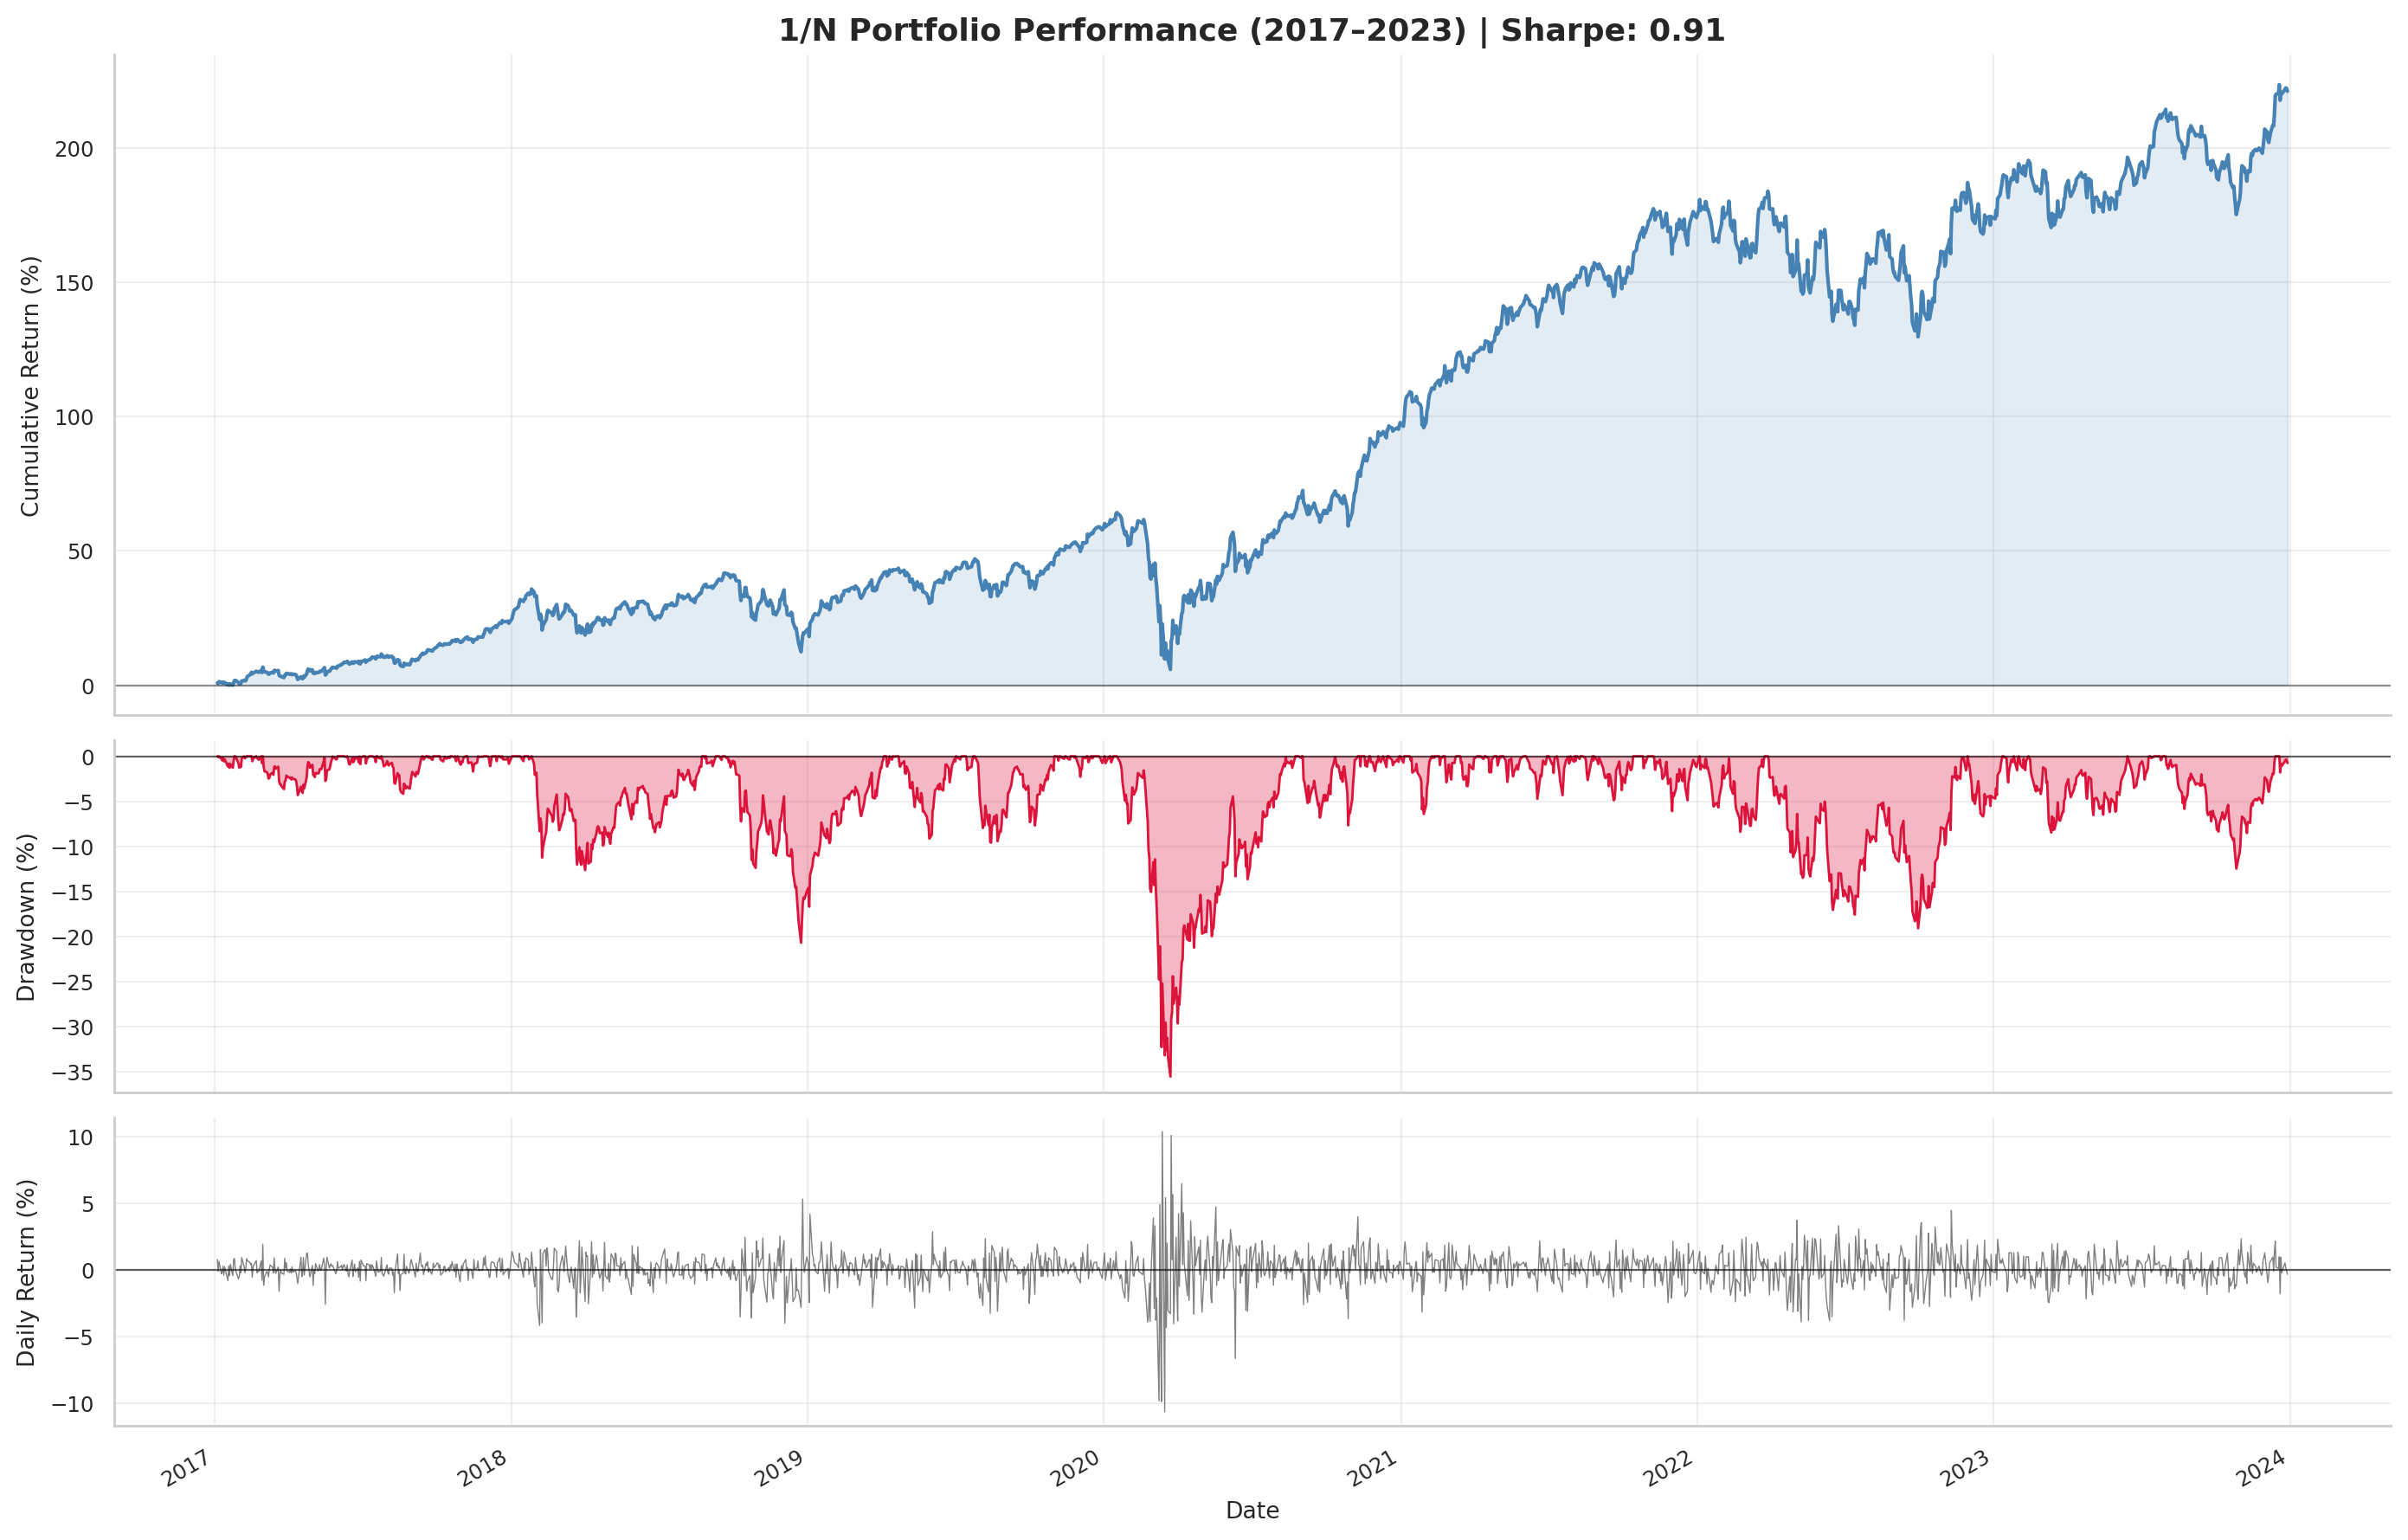

✓ Saved as 1n_performance.png


In [10]:
with sns.plotting_context("paper"):
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True,
                             gridspec_kw={"height_ratios": [3, 1.6, 1.4]})

    # Panel 1 — Cumulative return
    cum = (equity - 1).mul(100)
    cum.plot(ax=axes[0], color="steelblue", linewidth=1.5)
    axes[0].fill_between(cum.index, cum, 0, alpha=0.15, color="steelblue")
    axes[0].axhline(0, color="black", linewidth=0.8, alpha=0.4)
    axes[0].set_ylabel("Cumulative Return (%)")
    axes[0].set_title(
        f"1/N Portfolio Performance (2017\u20132023) | Sharpe: {sharpe:.2f}",
        fontsize=13, fontweight="bold"
    )
    axes[0].grid(True, alpha=0.3)

    # Panel 2 — Drawdown
    dd = drawdown.mul(100)
    dd.plot(ax=axes[1], color="crimson", linewidth=1)
    axes[1].fill_between(dd.index, dd, 0, alpha=0.3, color="crimson")
    axes[1].axhline(0, color="black", linewidth=0.8, alpha=0.6)
    axes[1].set_ylabel("Drawdown (%)")
    axes[1].grid(True, alpha=0.3)

    # Panel 3 — Daily returns
    portfolio_returns.mul(100).plot(ax=axes[2], color="gray", linewidth=0.5)
    axes[2].axhline(0, color="black", linewidth=0.8, alpha=0.6)
    axes[2].set_ylabel("Daily Return (%)")
    axes[2].grid(True, alpha=0.3)

    for ax in axes:
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.savefig("1n_performance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\u2713 Saved as 1n_performance.png")


**Overall performance:** The equally weighted (1/N) portfolio shows steady long-term growth over 2017–2023, confirming it is a reasonable benchmark allocation.

**Cumulative return:** The equity curve trends upward but with noticeable interim declines, indicating positive performance with normal market variability.

**Drawdowns:** Periodic drawdowns are present, with one clearly deeper episode than the rest. Losses are temporary and followed by recovery, consistent with diversified equity exposure.

**Daily returns:** Returns fluctuate around zero with occasional spikes, showing typical volatility clustering seen in equity portfolios.

**Risk-adjusted performance:** The Sharpe ratio (~0.91) indicates solid risk-adjusted returns for a simple equal-weight strategy.

**Role in the project:** This 1/N portfolio serves as a baseline benchmark against which optimized portfolios will be evaluated.

In [11]:
qs.reports.metrics(portfolio_returns, benchmark="SPY", mode="basic")


Parameter       Value
--------------  ---------------
Benchmark       Benchmark (SPY)
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Benchmark (SPY)    Strategy
-------------------  -----------------  ----------
Start Period         2017-01-05         2017-01-05
End Period           2023-12-29         2023-12-29
Risk-Free Rate       0.0%               0.0%
Time in Market       100.0%             100.0%

Cumulative Return    136.46%            218.57%
CAGR﹪               13.13%             18.07%

Sharpe               0.74               0.91
Prob. Sharpe Ratio   97.33%             99.08%
Sortino              1.03               1.28
Sortino/√2           0.73               0.91
Omega                1.16               1.19

Max Drawdown         -33.72%            -35.54%
Max DD Date          2020-03-23         2020-03-23
Max DD Period Start  2020-02-20         2020-01-21
Max DD Period End    2020-08-07         2020-08-21
Longest DD 

1/N Portfolio vs. SPY — Key Metrics

*   **Performance:** The 1/N portfolio outperformed SPY, delivering higher cumulative return (≈218.6% vs. ≈136.5%)

*   **Risk-adjusted return:** The portfolio achieved a stronger Sharpe ratio (0.91) than SPY (0.74), indicating better return per unit of risk.

*   **Downside risk:** Maximum drawdown (-35.5%) is slightly worse than SPY (-33.7%), suggesting marginally higher tail risk.

*  **Consistency:** Higher Sortino and Omega ratios for the strategy point to improved downside-adjusted performance relative to the benchmark.

*   **Volatility profile:** The portfolio remained fully invested and exhibits typical equity risk characteristics over the sample.

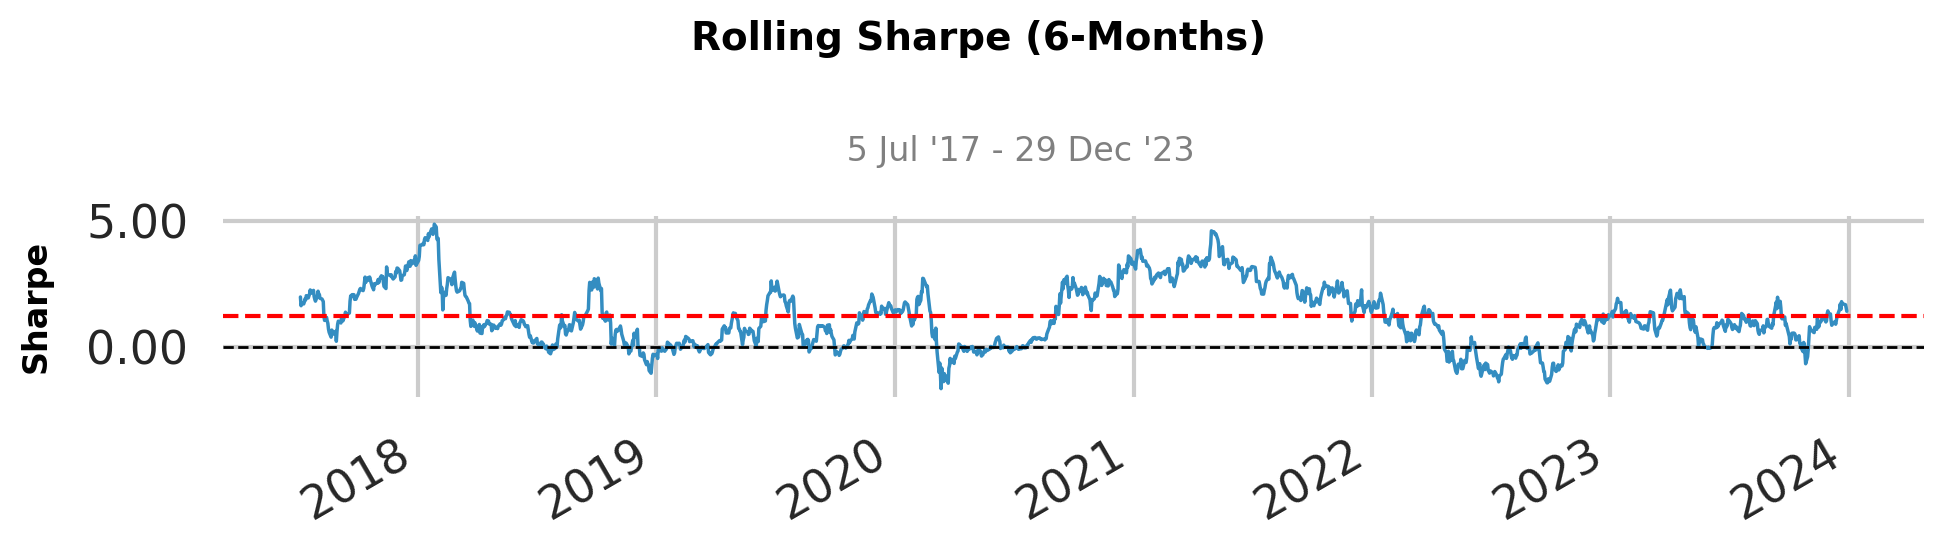

<Figure size 1200x800 with 0 Axes>

In [12]:
qs.plots.rolling_sharpe(portfolio_returns)
plt.tight_layout()
plt.show()

Rolling Sharpe — Key Takeaways

*   The chart shows the 6-month rolling Sharpe ratio of the equally weighted portfolio from mid-2017 to 2023, highlighting how risk-adjusted performance evolves over time.

*   The Sharpe ratio varies meaningfully across the sample, indicating that performance relative to volatility is not stable through time.


*   Periods where the rolling Sharpe approaches or falls below zero reflect weaker risk-adjusted performance, while peaks indicate stronger efficiency.

*   The red dashed line represents the full-sample average Sharpe, serving as a reference for short-term performance.

*   Conclusion: The portfolio’s risk-adjusted returns are time-varying, reinforcing the importance of evaluating performance dynamically rather than relying only on full-period metrics.

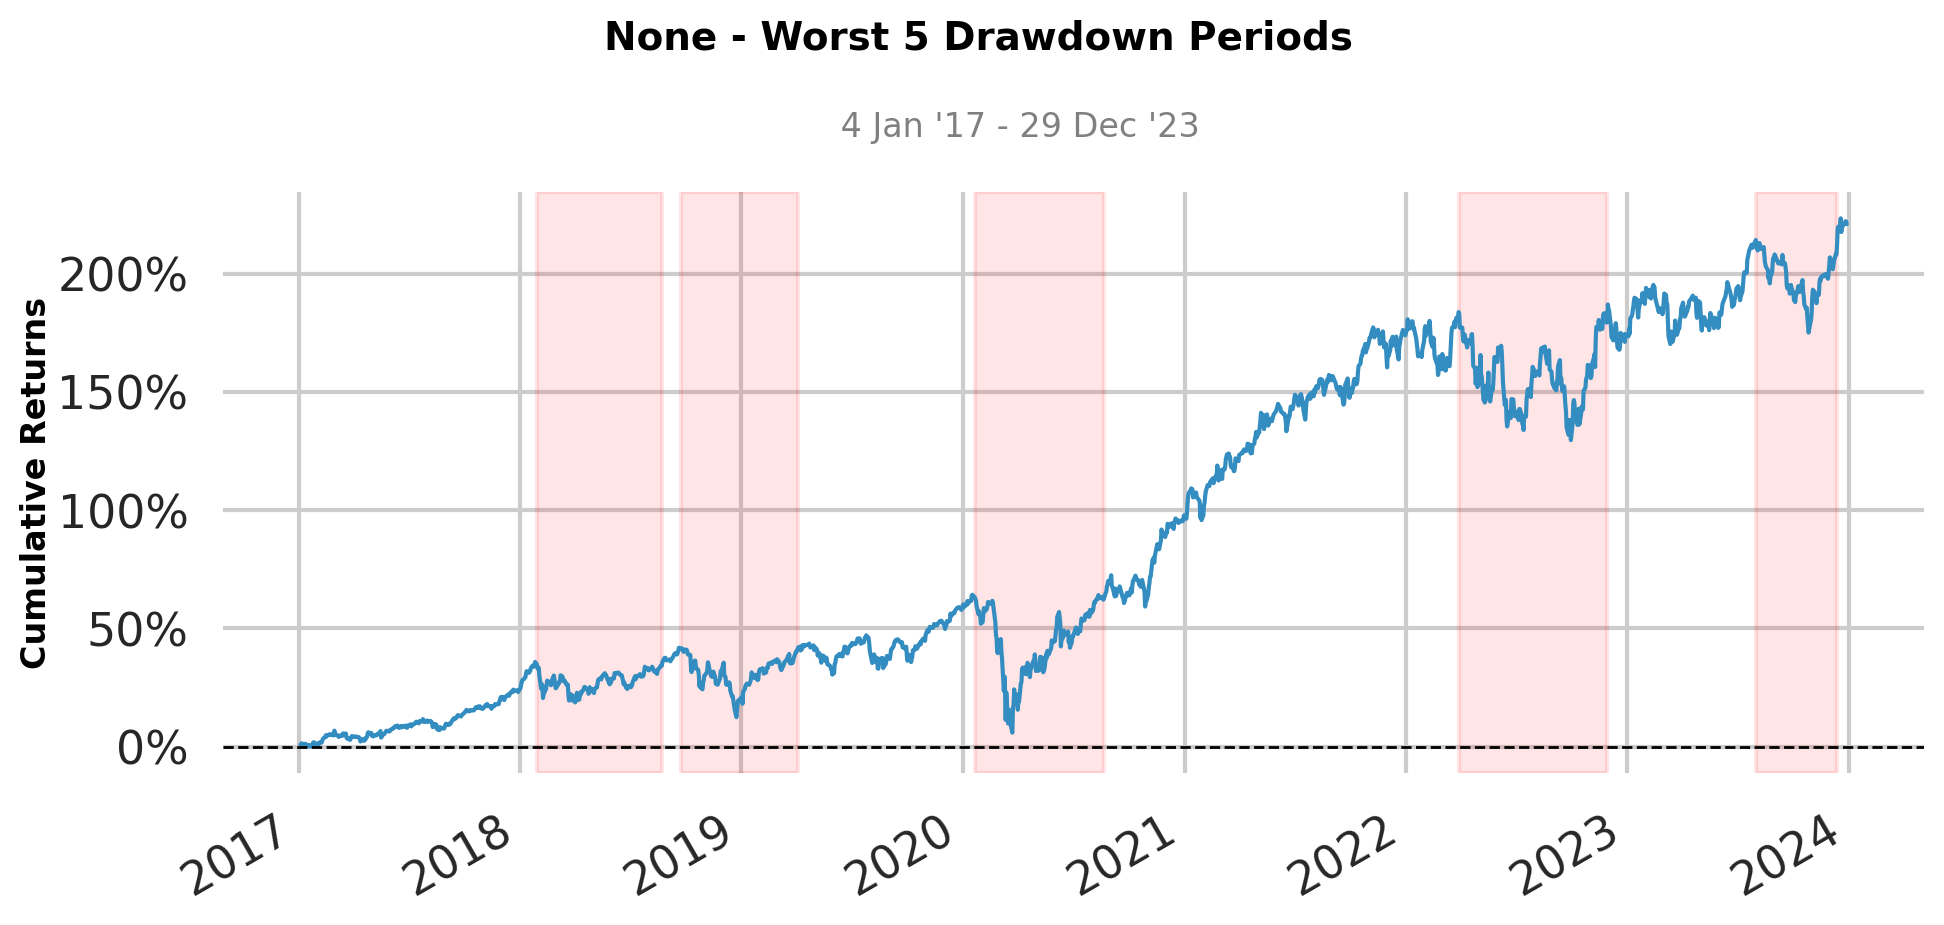

<Figure size 1200x800 with 0 Axes>

In [13]:
qs.plots.drawdowns_periods(portfolio_returns)
plt.tight_layout()
plt.show()

Worst Drawdown Periods — Key Takeaways



*   The chart shows cumulative returns of the 1/N portfolio with the five largest drawdown periods highlighted.

*   Shaded regions indicate episodes where the portfolio experienced the largest peak-to-trough losses.

*   The portfolio demonstrates strong long-term growth but is periodically exposed to meaningful temporary declines.


*   Multiple drawdown episodes appear across the sample, confirming that downside risk is recurring rather than isolated.





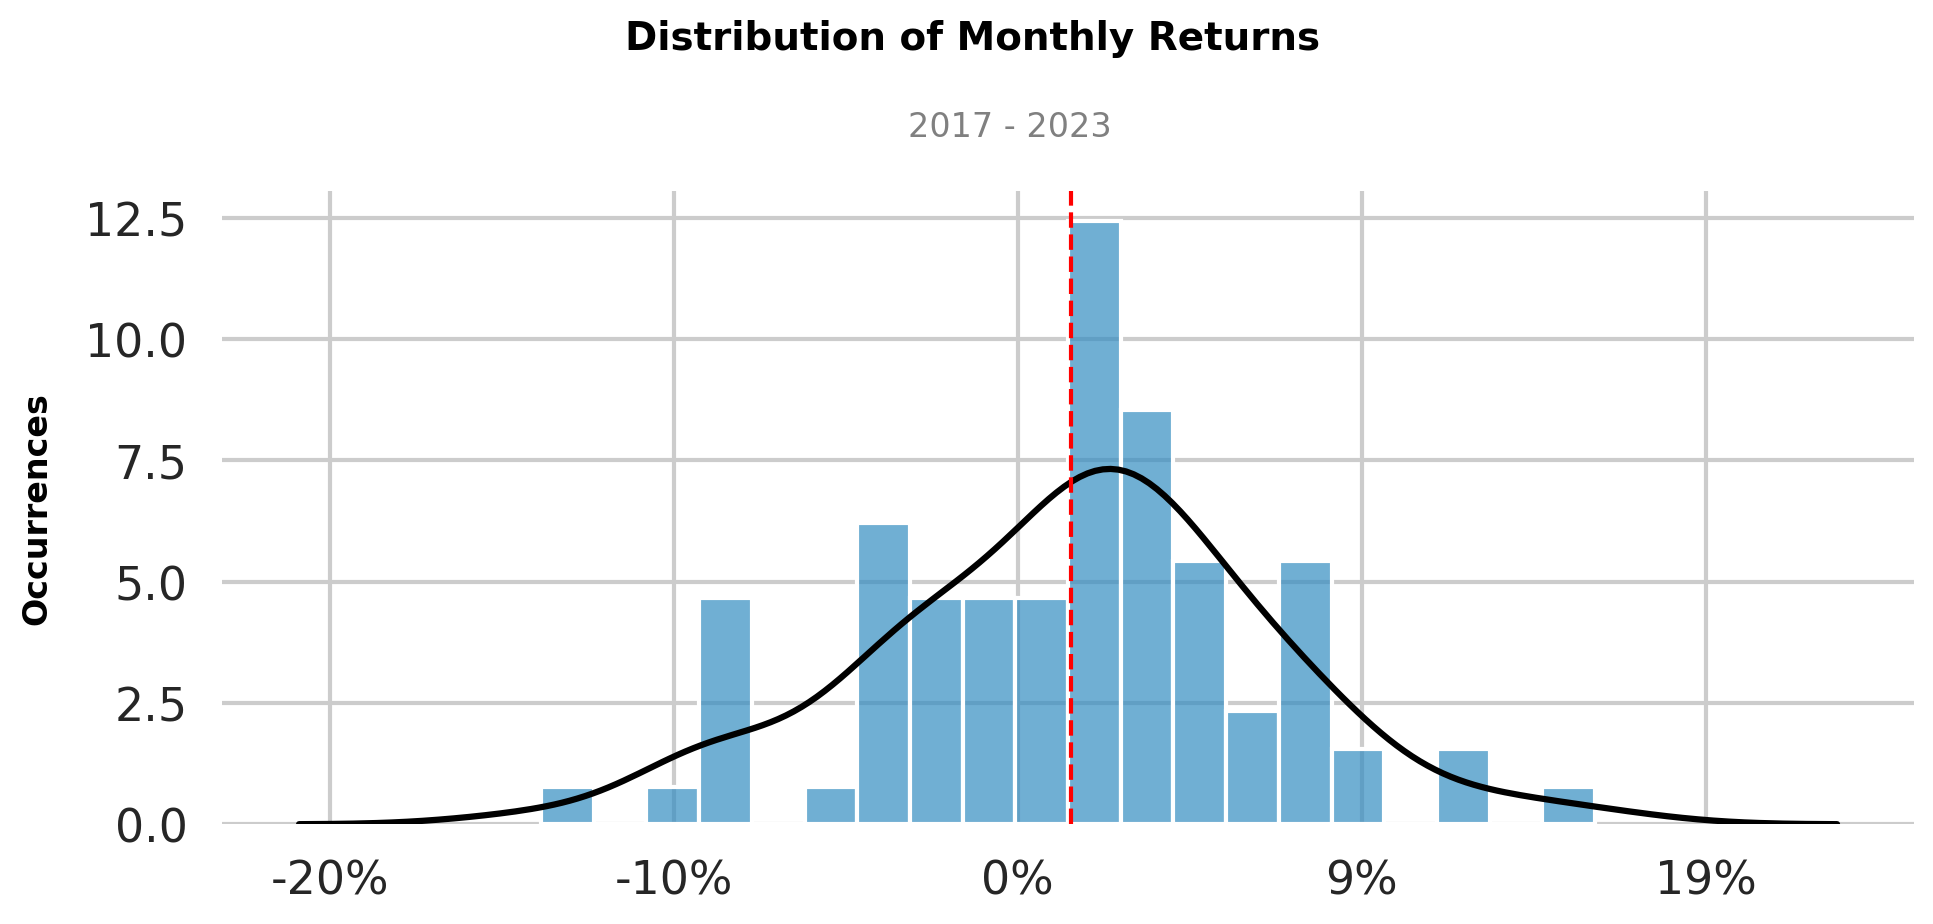

<Figure size 1200x800 with 0 Axes>

In [14]:
qs.plots.histogram(portfolio_returns)
plt.tight_layout()
plt.show()

The histogram shows the distribution of monthly returns for the 1/N portfolio from 2017–2023.

Returns are concentrated around small positive values, indicating the portfolio generated gains in many months.

The distribution is roughly bell-shaped but exhibits some asymmetry and tail events, which is typical for financial returns.

Takeaway: Monthly performance is generally stable but includes occasional larger positive and negative moves.

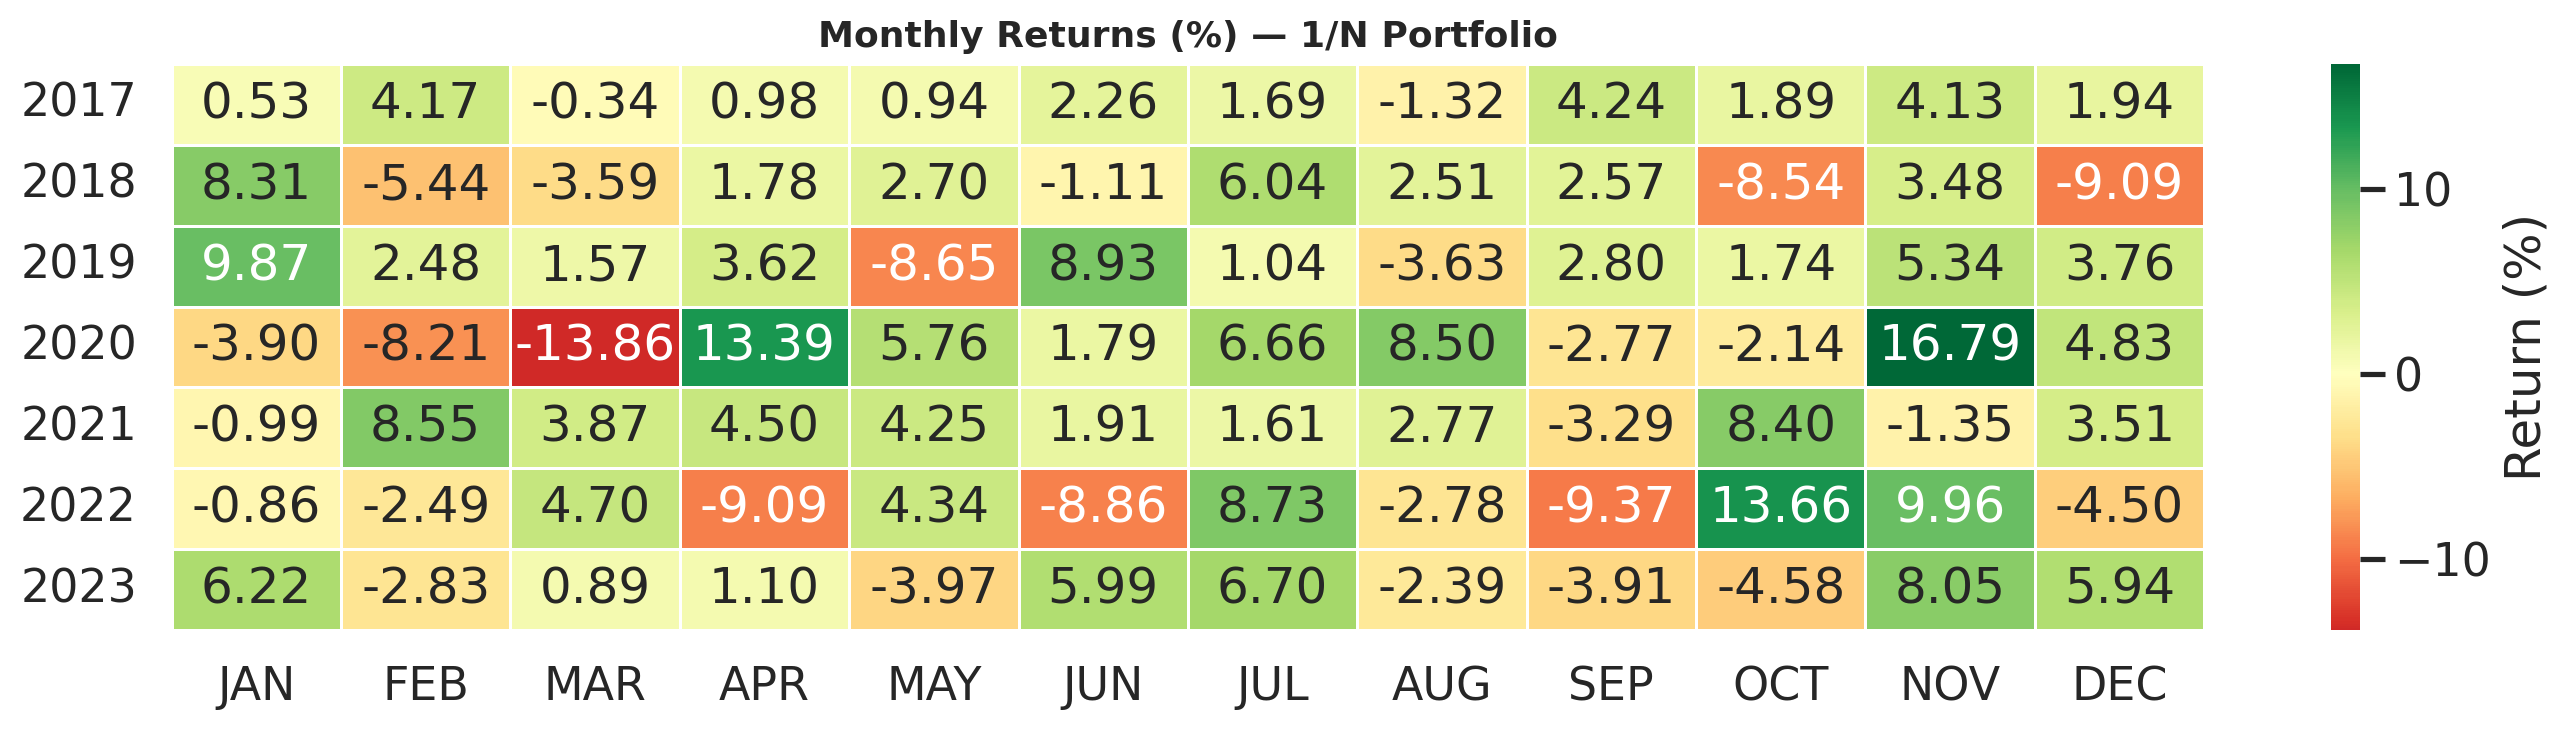

In [15]:
# ── Monthly Returns Heatmap
monthly = portfolio_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)

# Build pivot: rows = year, columns = month name
heat_df = pd.DataFrame({
    "Year":  monthly.index.year,
    "Month": monthly.index.month,
    "Return": monthly.values * 100,
})
heat_pivot = heat_df.pivot(index="Year", columns="Month", values="Return")
heat_pivot.columns = ["JAN","FEB","MAR","APR","MAY","JUN",
                       "JUL","AUG","SEP","OCT","NOV","DEC"]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heat_pivot, annot=True, fmt=".2f", center=0,
            cmap="RdYlGn", linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Return (%)"}, ax=ax)
ax.set_title("Monthly Returns (%) — 1/N Portfolio", fontsize=13, fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

The heatmap displays monthly returns of the 1/N portfolio from 2017–2023, with green indicating gains and red indicating losses.

Most months are positive, but losses appear intermittently across the sample, confirming variability in short-term performance.

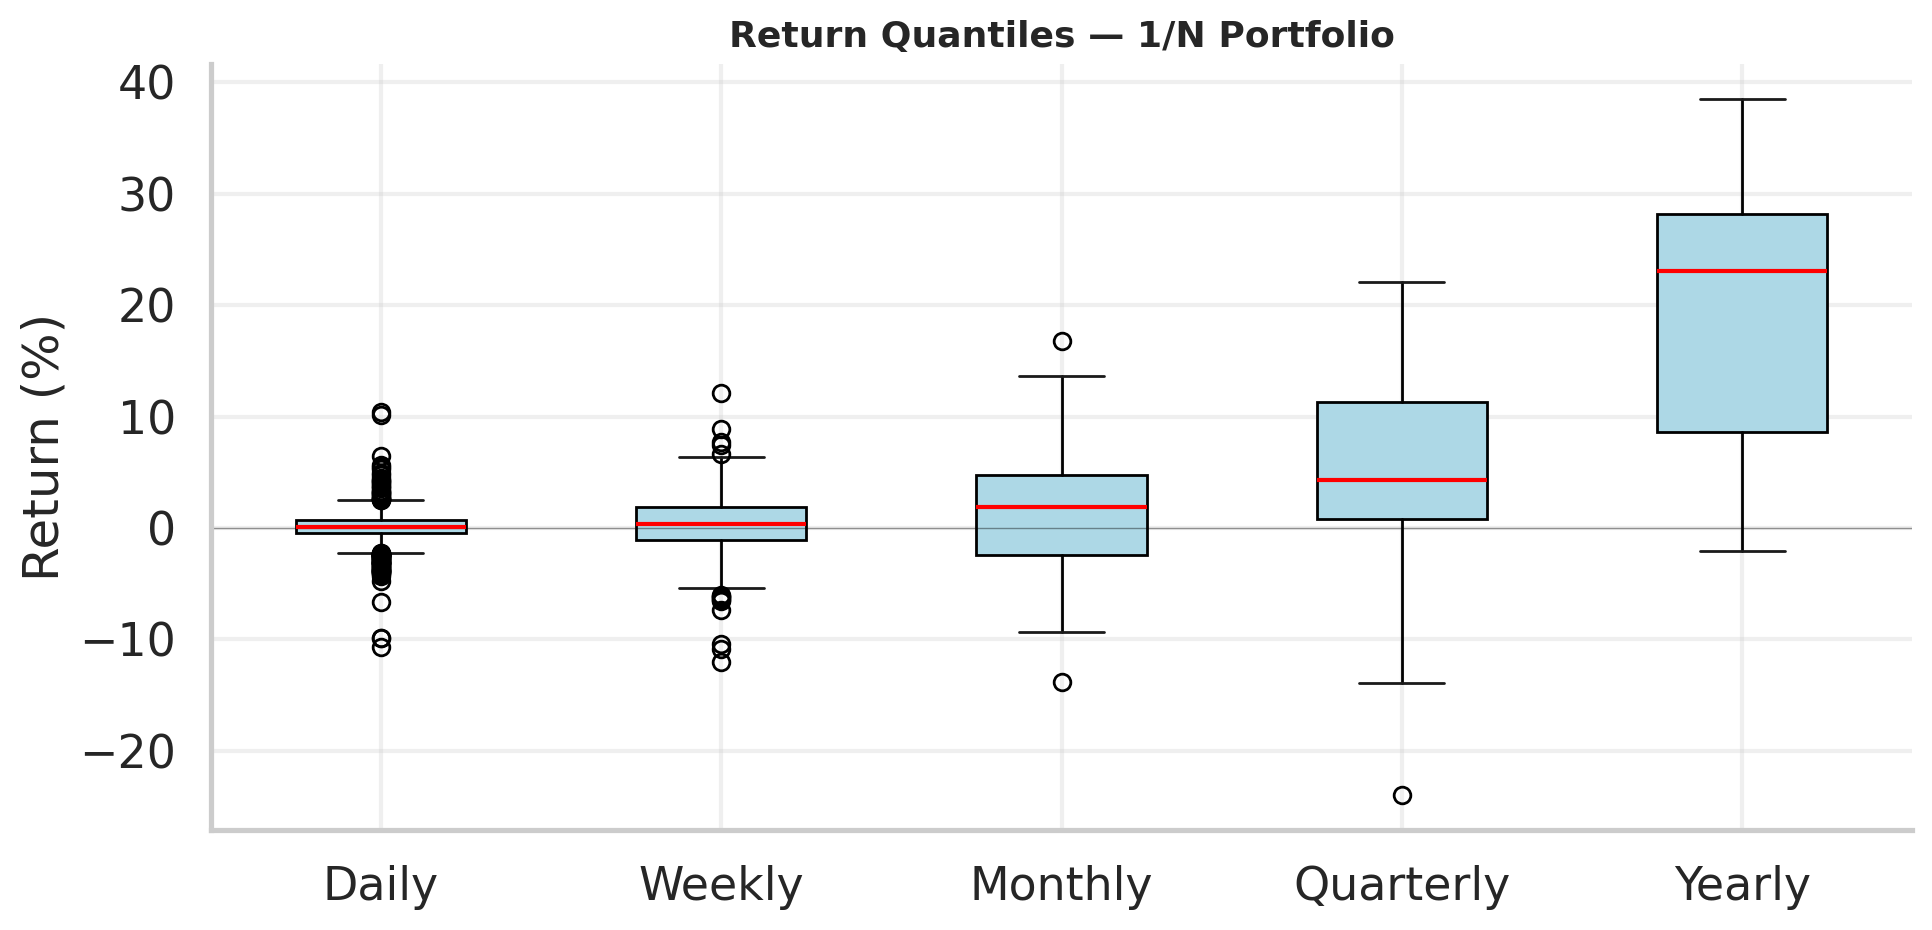

In [16]:
# ── Return Quantiles at Different Frequencies
daily_r    = portfolio_returns * 100
weekly_r   = portfolio_returns.resample("W").apply(lambda x: (1+x).prod()-1) * 100
monthly_r  = portfolio_returns.resample("ME").apply(lambda x: (1+x).prod()-1) * 100
quarterly_r = portfolio_returns.resample("QE").apply(lambda x: (1+x).prod()-1) * 100
yearly_r   = portfolio_returns.resample("YE").apply(lambda x: (1+x).prod()-1) * 100

quantile_data = pd.DataFrame({
    "Daily":     daily_r,
    "Weekly":    weekly_r,
    "Monthly":   monthly_r,
    "Quarterly": quarterly_r,
    "Yearly":    yearly_r,
})

fig, ax = plt.subplots(figsize=(10, 5))
quantile_data.boxplot(ax=ax, column=["Daily","Weekly","Monthly","Quarterly","Yearly"],
                      patch_artist=True,
                      boxprops=dict(facecolor="lightblue", color="black"),
                      medianprops=dict(color="red", linewidth=1.5))
ax.set_title("Return Quantiles — 1/N Portfolio", fontsize=13, fontweight="bold")
ax.set_ylabel("Return (%)")
ax.axhline(0, color="black", linewidth=0.5, alpha=0.4)
ax.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

The boxplots compare the distribution of portfolio returns across different time horizons (daily to yearly).

As the horizon increases, both the median return and the dispersion widen, reflecting the compounding effect of returns over time.

Short-horizon returns cluster tightly around zero, while longer horizons show greater variability and higher central values.

Takeaway: Return magnitude and risk both scale with the investment horizon, consistent with typical portfolio behavior.

## 4. Optimization Problem Setup

We work with annualized simple-return statistics

In [17]:
# Annualized parameters (from simple returns)
mu_val  = returns_df.mean().values * N_DAYS    # shape (20,)
cov_val = returns_df.cov().values  * N_DAYS    # shape (20, 20)
rf      = 0.0                                  # risk-free rate

# 1/N statistics in the simple-return framework (for consistent comparison)
w_eq      = np.ones(n_assets) / n_assets
ret_eq    = float(w_eq @ mu_val)
risk_eq   = float(np.sqrt(w_eq @ cov_val @ w_eq))
sharpe_eq = (ret_eq - rf) / risk_eq

print("=== Annualized Expected Returns per Asset ===")
for tk, r in zip(ASSETS, mu_val):
    print(f"  {tk:6s}: {r*100:>7.2f}%")

print(f"\n=== 1/N Baseline (simple-return framework) ===")
print(f"  Return   : {ret_eq*100:.2f}%")
print(f"  Std Dev  : {risk_eq*100:.2f}%")
print(f"  Sharpe   : {sharpe_eq:.4f}")


=== Annualized Expected Returns per Asset ===
  GS    :   13.38%
  MS    :   19.15%
  SCHW  :   15.39%
  JNJ   :    8.87%
  ABBV  :   20.90%
  TMO   :   22.43%
  XOM   :   10.78%
  SLB   :    5.60%
  EOG   :   15.04%
  COST  :   25.12%
  NKE   :   16.47%
  SBUX  :   13.90%
  CAT   :   23.79%
  DE    :   25.82%
  UPS   :   11.44%
  AMD   :   52.17%
  ORCL  :   20.04%
  CRM   :   25.09%
  CMCSA :    9.17%
  LIN   :   22.87%

=== 1/N Baseline (simple-return framework) ===
  Return   : 18.87%
  Std Dev  : 20.72%
  Sharpe   : 0.9109


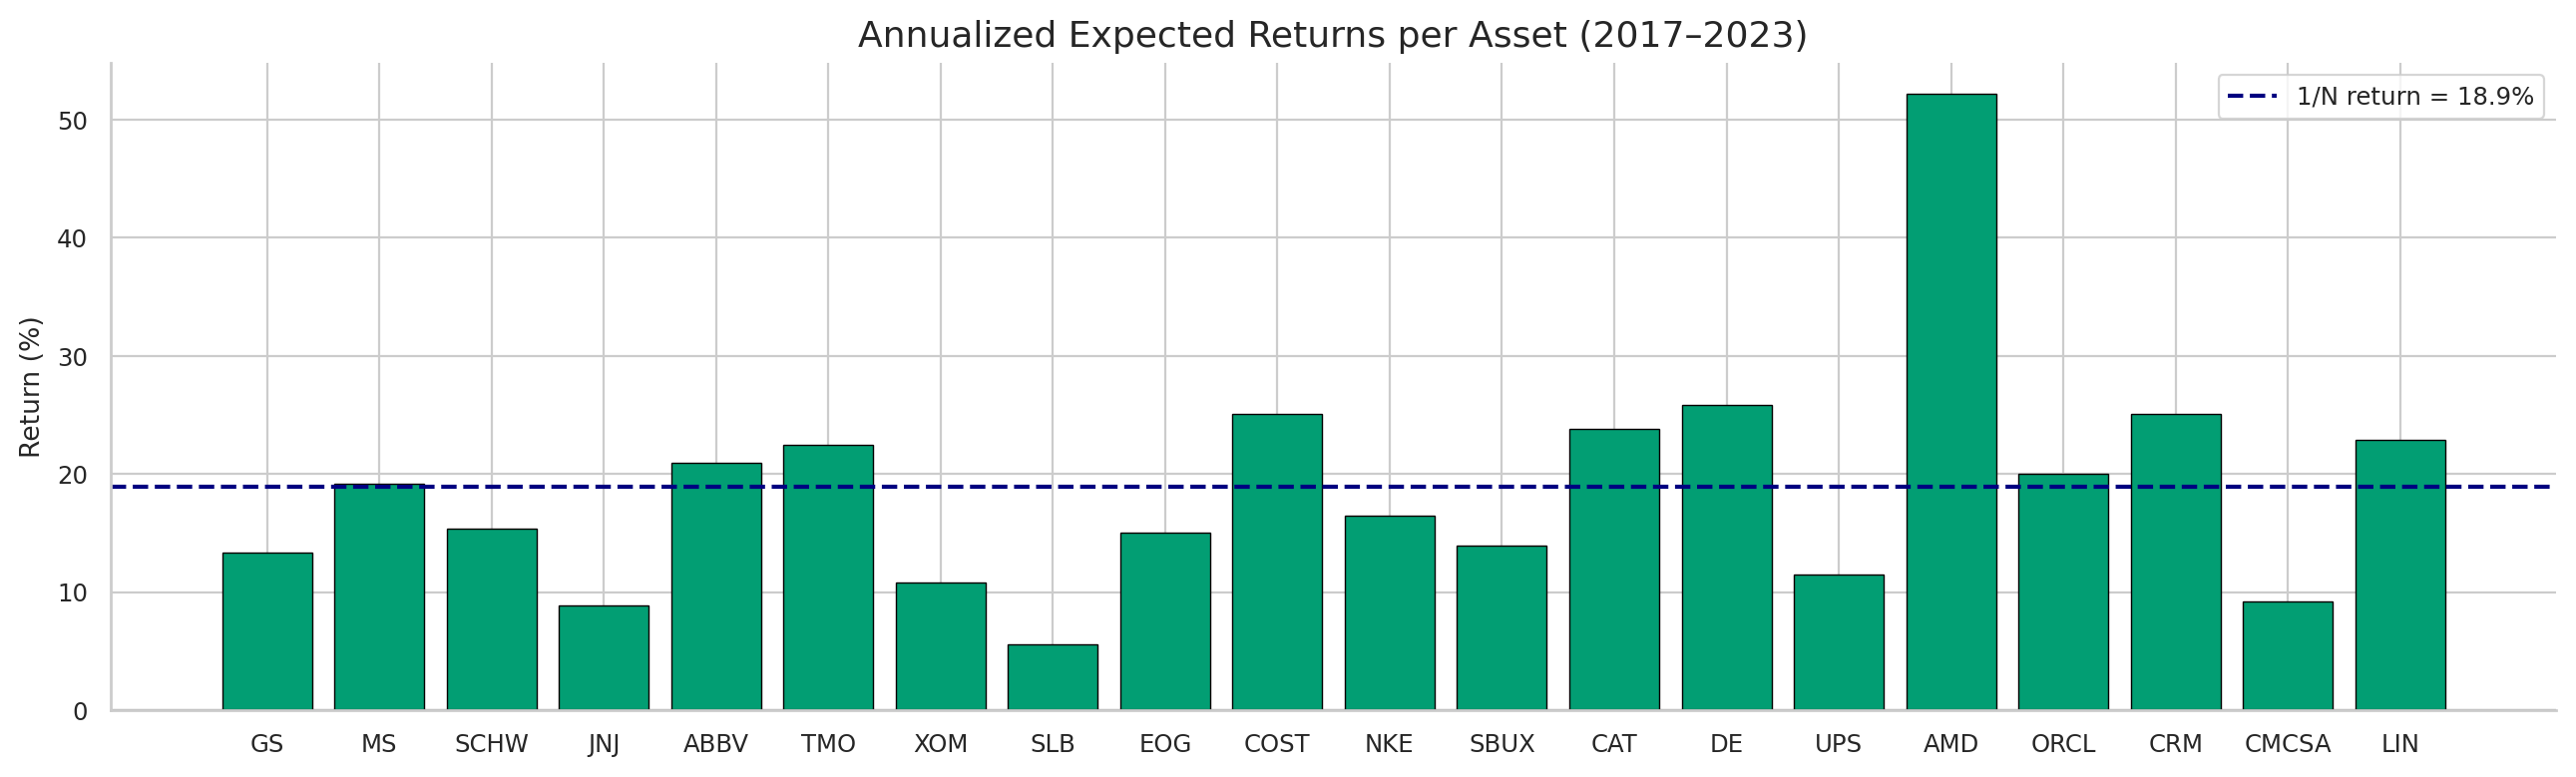

In [18]:
with sns.plotting_context("paper"):
    fig, ax = plt.subplots(figsize=(13, 4))
    colors = ["g" if r > 0 else "r" for r in mu_val]
    ax.bar(ASSETS, mu_val * 100, color=colors, edgecolor="black", linewidth=0.5)
    ax.axhline(ret_eq * 100, color="navy", linestyle="--", linewidth=1.5,
               label=f"1/N return = {ret_eq*100:.1f}%")
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.4)
    ax.set_title("Annualized Expected Returns per Asset (2017\u20132023)",
                 fontsize=13)
    ax.set_ylabel("Return (%)")
    ax.legend()
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()


## 5. Monte Carlo Simulation

We simulate **500,000 random long-only portfolios** by drawing weights from
a Dirichlet distribution.
This maps out the **feasible region** and gives an intuitive picture of the
efficient frontier before applying formal optimization.


In [25]:
N_MC = 500_000
np.random.seed(42)

mc_weights  = np.random.dirichlet(np.ones(n_assets), N_MC)
mc_returns  = mc_weights @ mu_val
mc_vols     = np.sqrt(np.einsum("ij,jk,ik->i", mc_weights, cov_val, mc_weights))
mc_sharpes  = (mc_returns - rf) / mc_vols

portf_results_df = pd.DataFrame({
    "returns":      mc_returns,
    "volatility":   mc_vols,
    "sharpe_ratio": mc_sharpes,
})

print(f"Simulated portfolios : {N_MC:,}")
print(f"Return range         : {mc_returns.min()*100:.2f}% \u2192 {mc_returns.max()*100:.2f}%")
print(f"Volatility range     : {mc_vols.min()*100:.2f}% \u2192 {mc_vols.max()*100:.2f}%")
print(f"Max Sharpe found     : {mc_sharpes.max():.4f}")
portf_results_df


Simulated portfolios : 500,000
Return range         : 11.47% → 36.30%
Volatility range     : 17.04% → 35.84%
Max Sharpe found     : 1.2331


,returns,volatility,sharpe_ratio
0,0.168,0.228,0.734
1,0.201,0.216,0.932
2,0.217,0.221,0.982
3,0.207,0.205,1.009
4,0.179,0.233,0.767
...,...,...,...
499995,0.187,0.215,0.869
499996,0.195,0.218,0.894
499997,0.172,0.213,0.807
499998,0.219,0.236,0.927


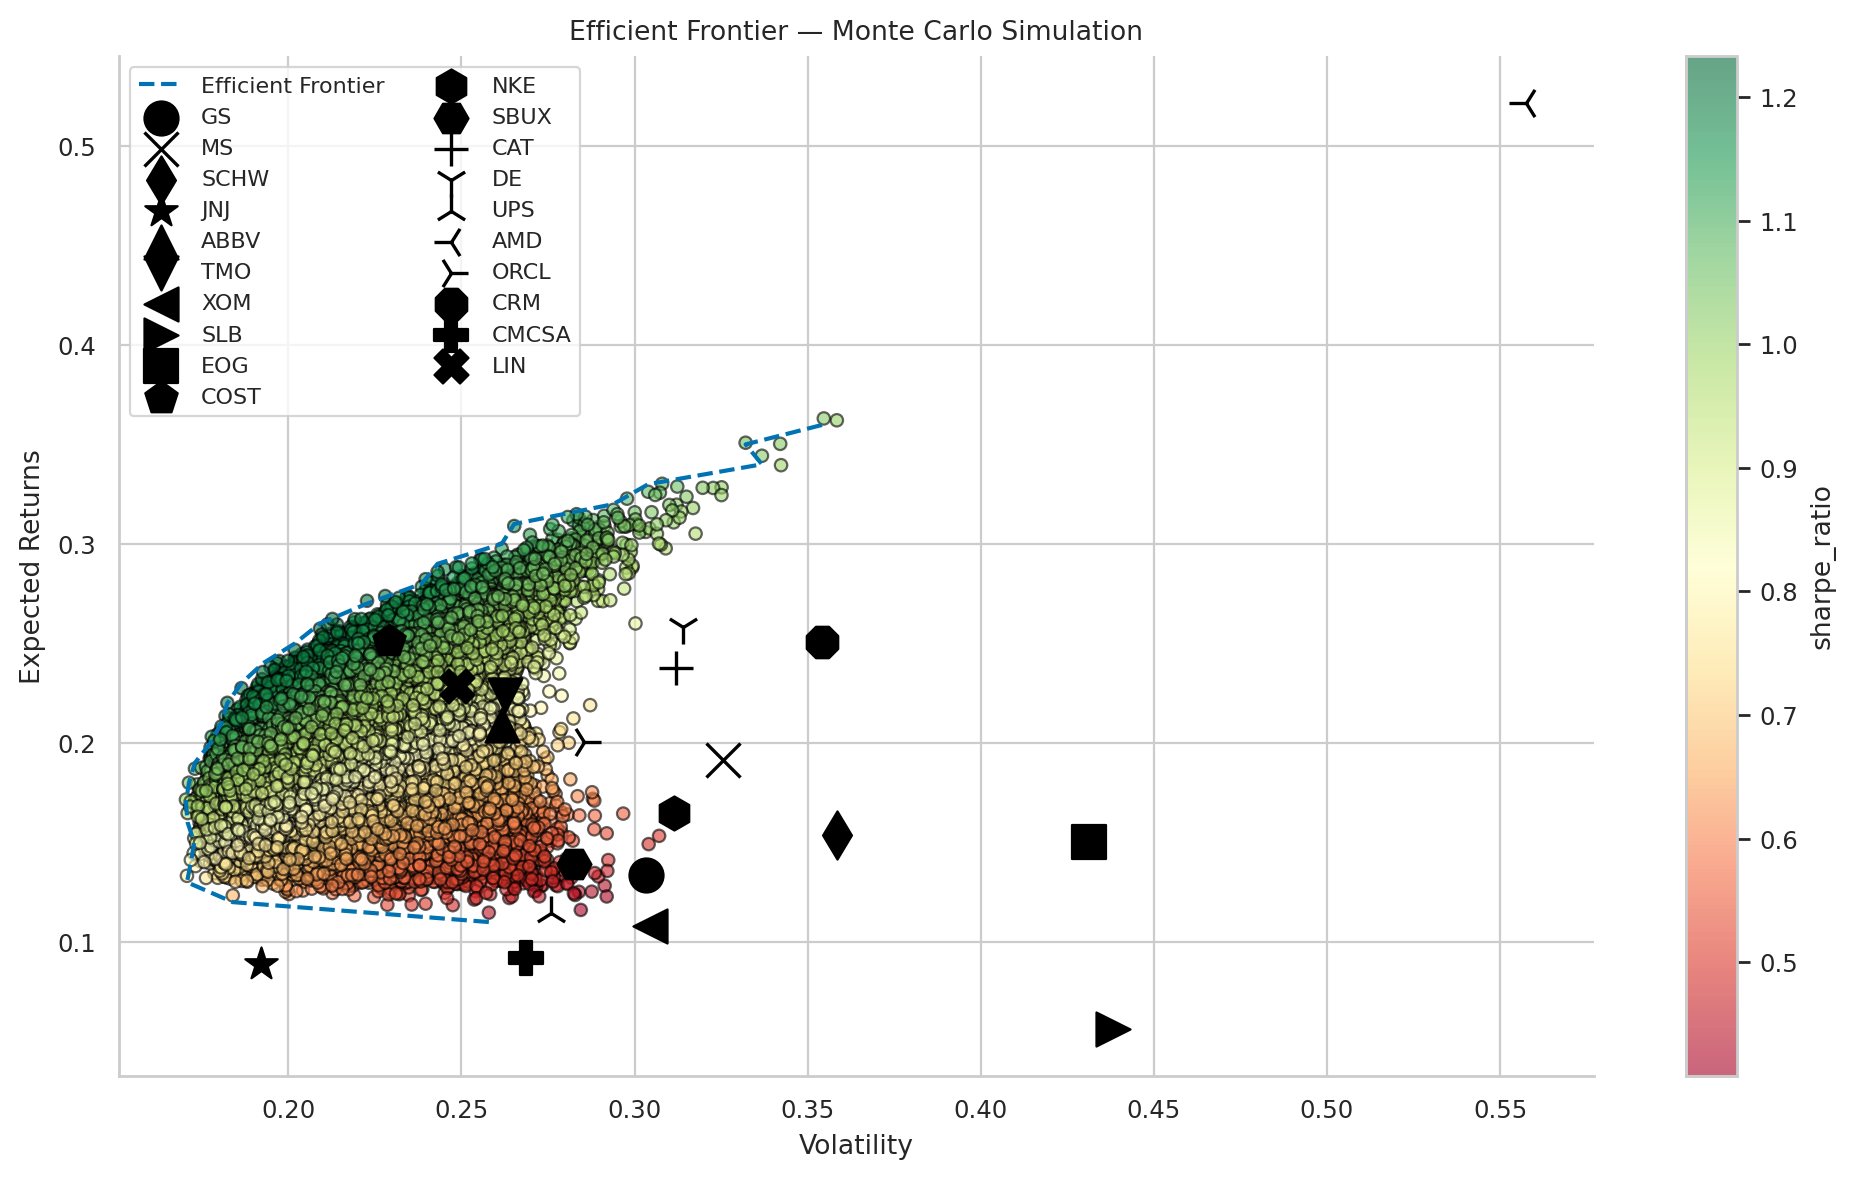

In [26]:
# Build MC-based efficient frontier curve (minimum vol at each return level)
N_POINTS = 10000
ef_rtn_list, ef_vol_list = [], []

possible_ef_rtns  = np.round(np.linspace(mc_returns.min(), mc_returns.max(), N_POINTS), 2)
portf_rtns_rounded = np.round(mc_returns, 2)

for rtn in possible_ef_rtns:
    if rtn in portf_rtns_rounded:
        ef_rtn_list.append(rtn)
        matched = np.where(portf_rtns_rounded == rtn)
        ef_vol_list.append(np.min(mc_vols[matched]))

with sns.plotting_context("paper"):
    fig, ax = plt.subplots(figsize=(10, 6))

    portf_results_df.plot(
        kind="scatter",
        x="volatility",
        y="returns",
        c="sharpe_ratio",
        cmap="RdYlGn",
        edgecolors="black",
        ax=ax,
        alpha=0.6
    )

    # Efficient frontier curve (MC-derived)
    ax.plot(ef_vol_list, ef_rtn_list, "b--", linewidth=1.5,
            label="Efficient Frontier")

    # Individual assets with distinct markers
    for i in range(n_assets):
        ax.scatter(
            x=np.sqrt(cov_val[i, i]),
            y=mu_val[i],
            marker=MARKERS[i],
            s=150,
            color="black",
            label=ASSETS[i]
        )

    ax.set(
        xlabel="Volatility",
        ylabel="Expected Returns",
        title="Efficient Frontier — Monte Carlo Simulation"
    )
    ax.legend(loc="best", fontsize=8, ncol=2)
    sns.despine()
    plt.tight_layout()
    plt.show()


The scatter plot shows the feasible set of long-only portfolios generated via Monte Carlo simulation, with volatility on the x-axis and expected return on the y-axis.

The color gradient represents the Sharpe ratio, where greener points indicate better risk-adjusted performance.

The dashed upper envelope represents the empirical efficient frontier — portfolios that offer the highest expected return for each level of risk.

Most randomly generated portfolios lie below the frontier, confirming they are mean-variance inefficient relative to the best combinations.

Individual stocks appear mostly to the right and/or below the frontier, illustrating the diversification benefit from combining assets.

Takeaway: diversification improves the risk-return trade-off, and the Monte Carlo cloud provides a visual approximation of the feasible portfolio region

## 6. Efficient Frontier — CVXPY Optimization

We compute the efficient frontier using two complementary approaches:


### 6.1 Method 1 — Risk-Aversion


In [28]:
N_GAMMA = 200
gammas  = np.logspace(-2, 3, N_GAMMA)

w_cvx       = cp.Variable(n_assets)
gamma_par   = cp.Parameter(nonneg=True)

portf_rtn_cvx = mu_val  @ w_cvx
portf_var_cvx = cp.quad_form(w_cvx, cov_val)

problem_cvx = cp.Problem(
    cp.Maximize(portf_rtn_cvx - gamma_par * portf_var_cvx),
    [cp.sum(w_cvx) == 1, w_cvx >= 0]
)

ret_cvxpy, risk_cvxpy, weights_cvxpy = [], [], []

for g in gammas:
    gamma_par.value = g
    problem_cvx.solve(solver=cp.OSQP, eps_abs=1e-8, eps_rel=1e-8)
    if problem_cvx.status in ["optimal", "optimal_inaccurate"]:
        wv = w_cvx.value
        ret_cvxpy.append(float(mu_val @ wv))
        risk_cvxpy.append(float(np.sqrt(wv @ cov_val @ wv)))
        weights_cvxpy.append(wv)

ret_cvxpy  = np.array(ret_cvxpy)
risk_cvxpy = np.array(risk_cvxpy)
print(f"CVXPY (\u03b3 sweep): {len(ret_cvxpy)} feasible points")


CVXPY (γ sweep): 200 feasible points


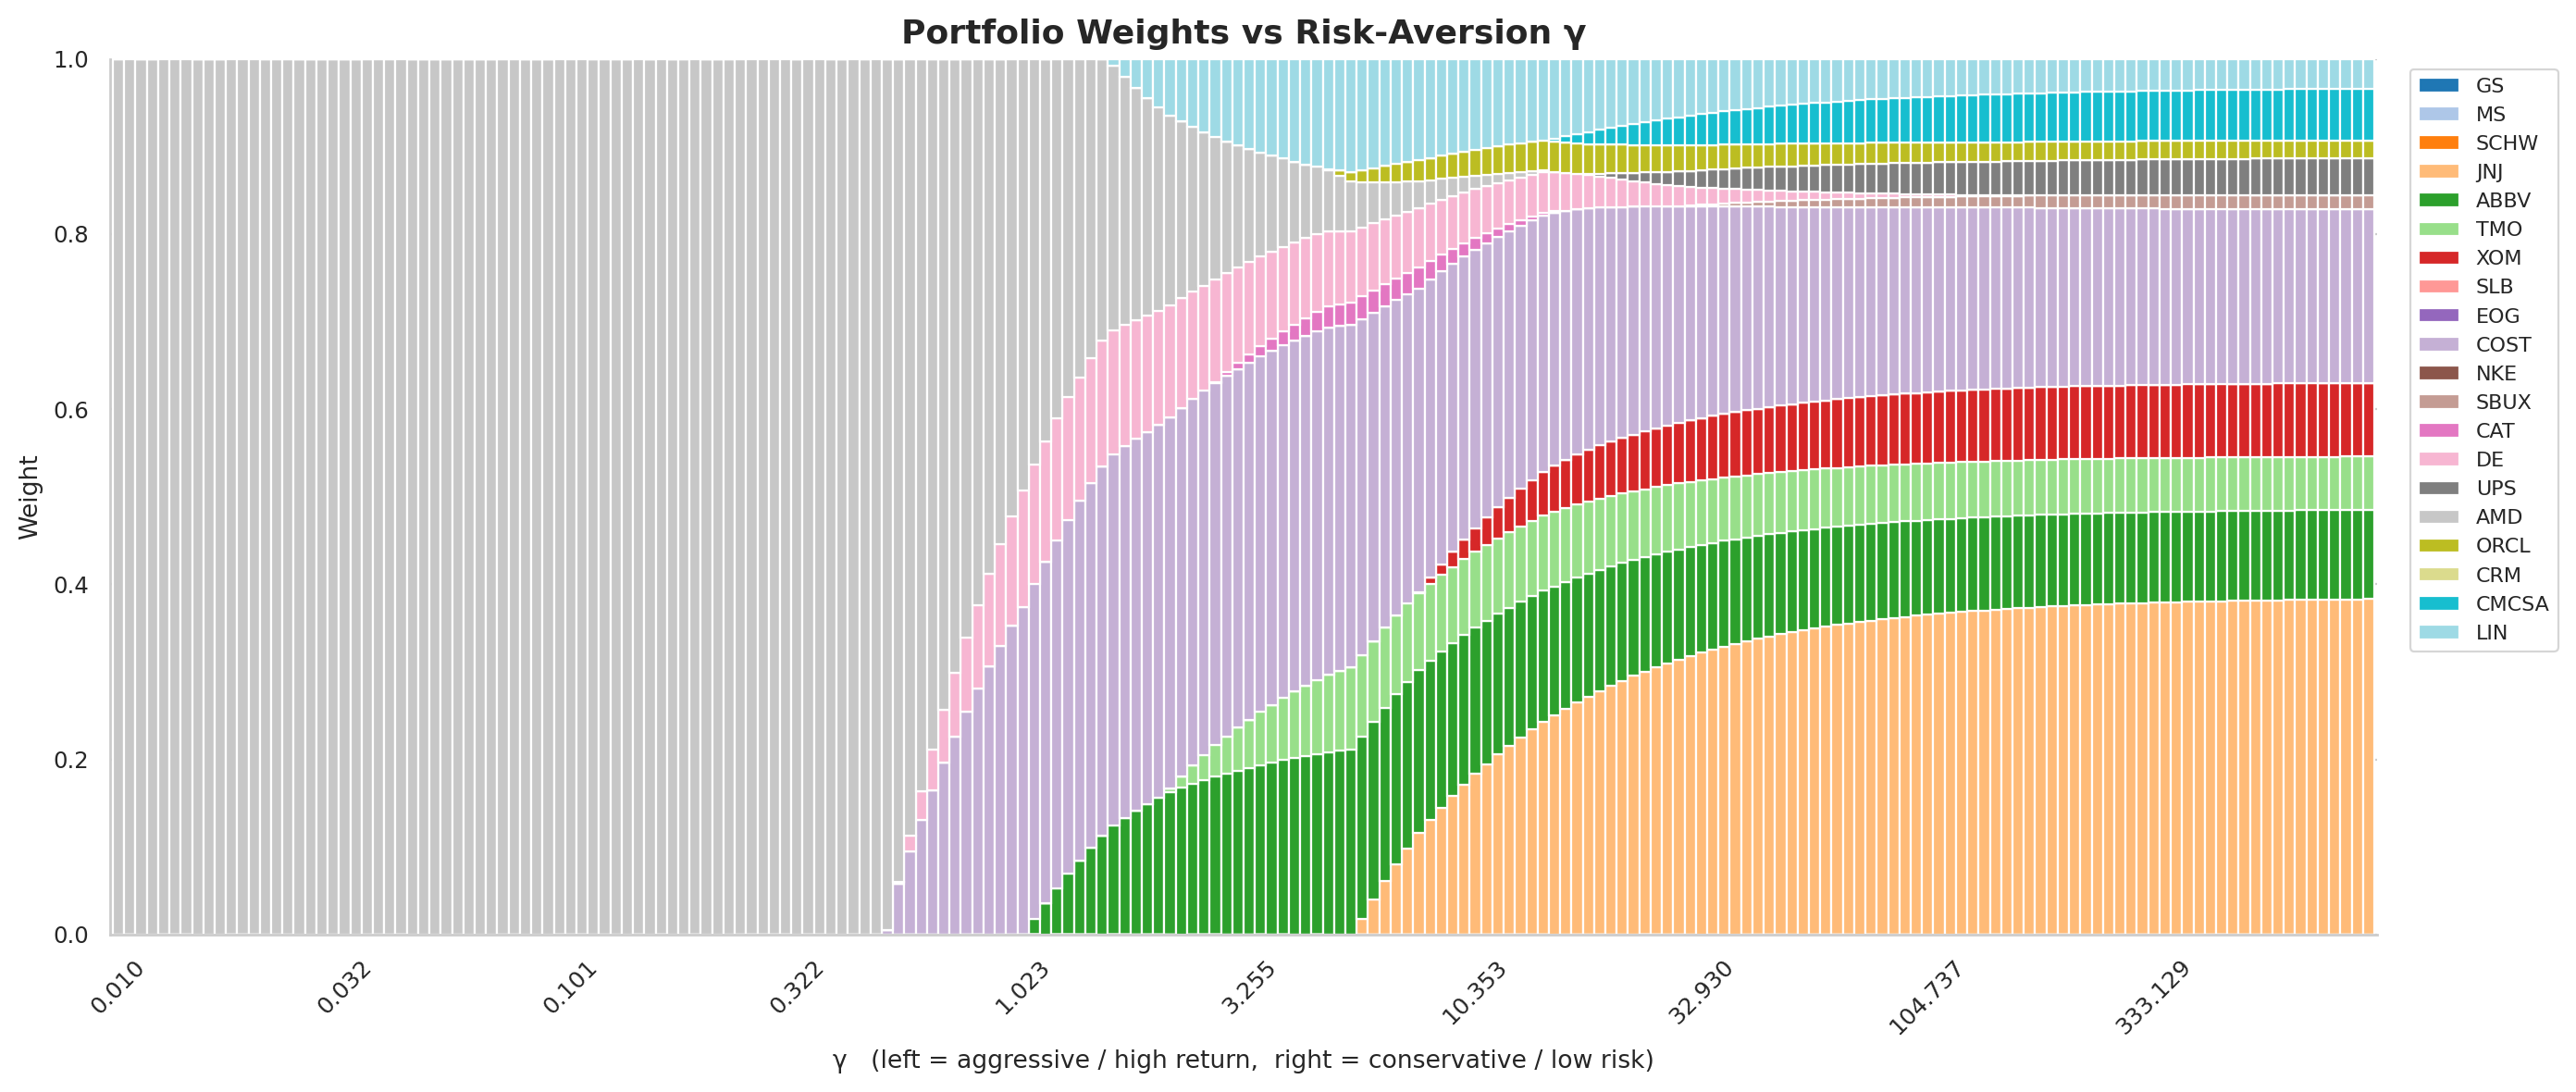

In [29]:
weights_gamma_df = pd.DataFrame(weights_cvxpy, columns=ASSETS)

with sns.plotting_context("paper"):
    ax = weights_gamma_df.plot(kind="bar", stacked=True, figsize=(14, 6),
                               colormap="tab20", width=1.0)
    ax.set_title("Portfolio Weights vs Risk-Aversion \u03b3",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("\u03b3   (left = aggressive / high return,  right = conservative / low risk)")
    ax.set_ylabel("Weight")

    ticks = range(0, len(weights_gamma_df), len(weights_gamma_df) // 10)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{gammas[i]:.3f}" for i in ticks], rotation=45, fontsize=9)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

    sns.despine()
    plt.tight_layout()
    plt.show()


This figure shows how the optimal portfolio weights change as the risk-aversion parameter γ varies in the mean-variance optimization framework. T

On the left side of the graph, where γ is low, the portfolio is concentrated in a smaller number of assets, indicating that the optimizer prioritizes expected return over variance. In this region, weights are more extreme and less diversified, reflecting stronger emphasis on assets with higher estimated returns regardless of their volatility contribution.

As γ increases, the allocation gradually shifts and becomes more diversified. The weights spread across a larger number of assets, and extreme concentrations diminish. This transition reflects the increasing penalty applied to portfolio variance in the objective function as risk aversion rises.

Toward the right side of the graph, where γ is high, the portfolio composition stabilizes into a more balanced structure, with allocations distributed more evenly across several assets. This corresponds to portfolios closer to the minimum-variance region of the efficient frontier, where risk minimization dominates the optimization problem.

The smooth evolution of weights across γ demonstrates how mean-variance optimization systematically adjusts asset allocation in response to changing trade-offs between expected return and risk.

Overall, the figure visually confirms the theoretical result that portfolio composition is directly driven by the investor’s risk-aversion parameter within the quadratic optimization framework.

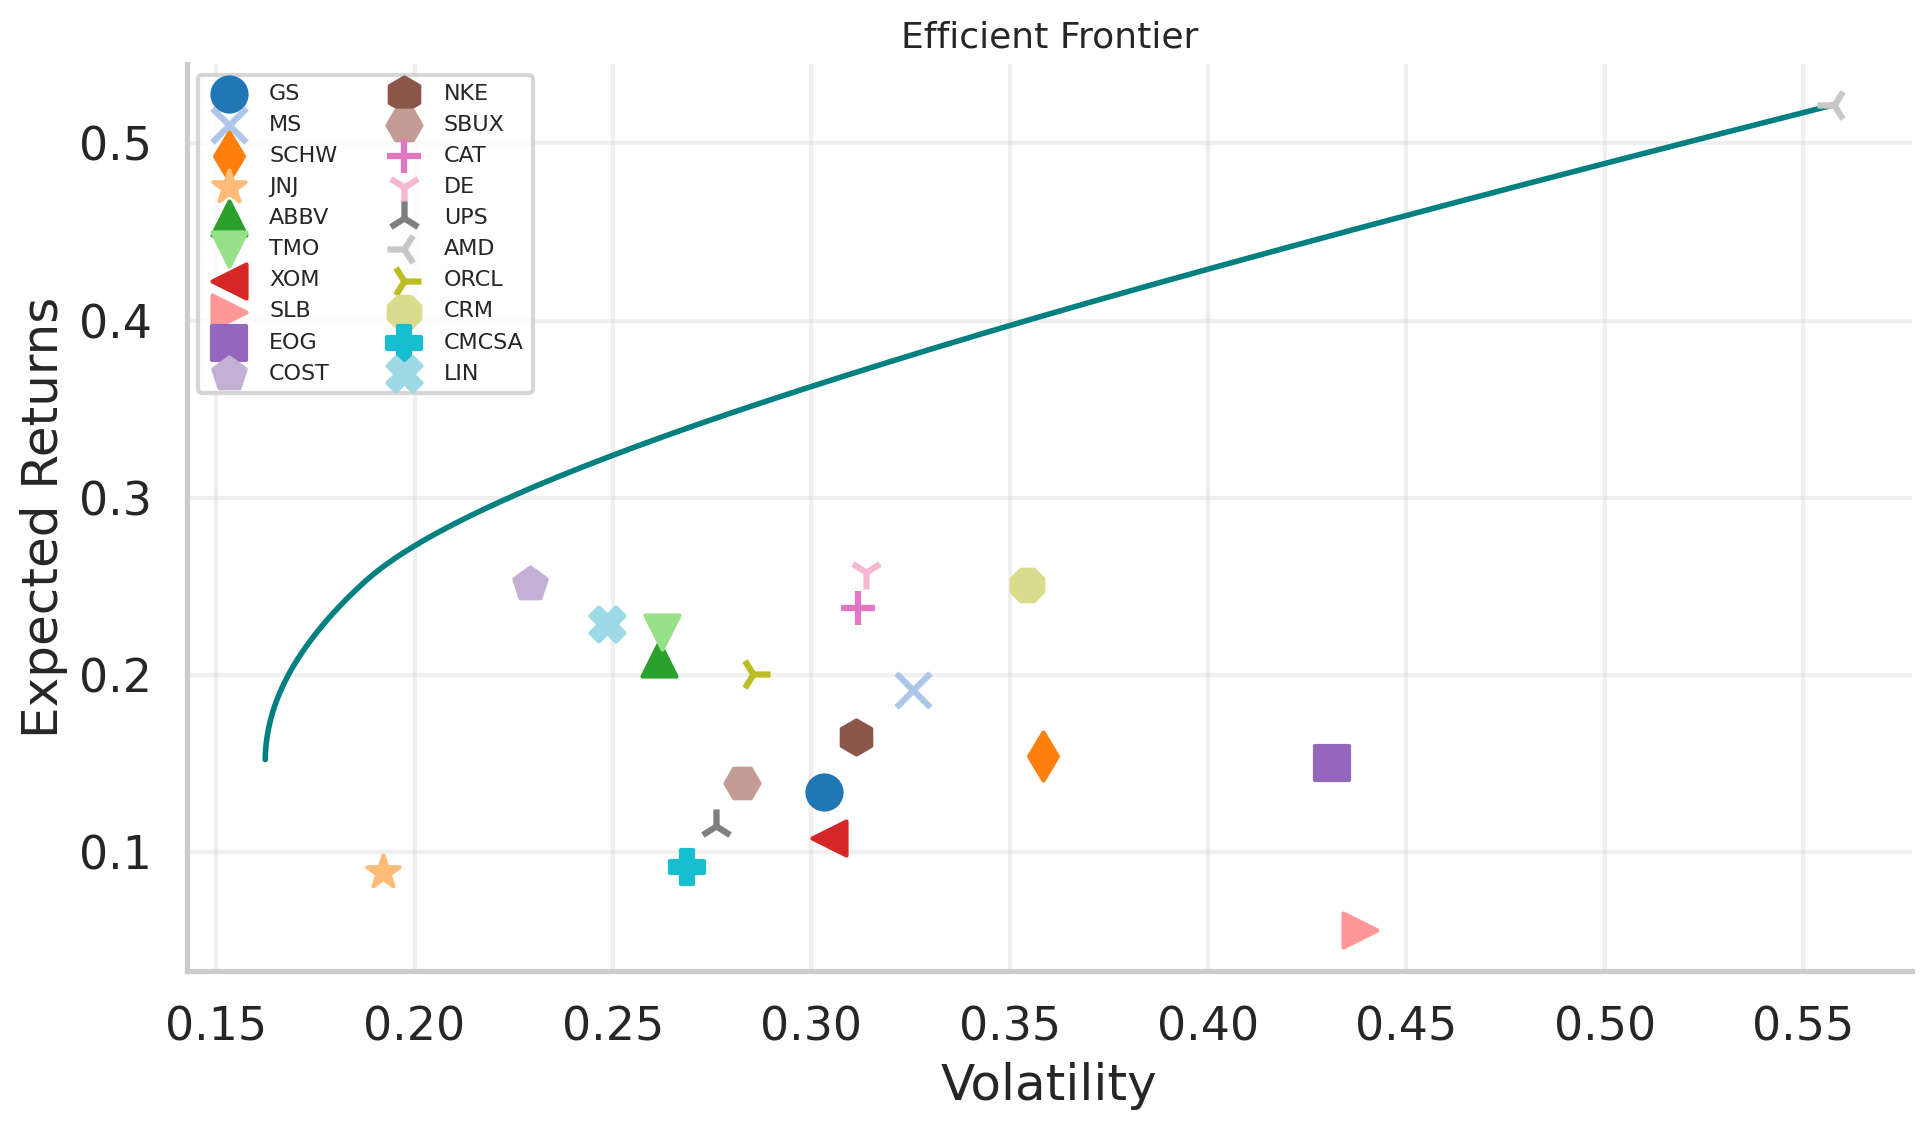

In [30]:
vols_ind = np.sqrt(np.diag(cov_val))
fig, ax = plt.subplots(figsize=(10, 6))

# CVXPY efficient frontier curve
ax.plot(risk_cvxpy, ret_cvxpy, color="teal", linewidth=2)

# Individual assets — each with its own color from the tab20 colormap
colors = plt.cm.tab20(np.linspace(0, 1, n_assets))

for i, tk in enumerate(ASSETS):
    ax.scatter(
        vols_ind[i], mu_val[i],
        marker=MARKERS[i], s=150,
        color=colors[i],
        label=tk, zorder=5
    )

ax.set_title("Efficient Frontier", fontsize=13)
ax.set_xlabel("Volatility")
ax.set_ylabel("Expected Returns")
ax.legend(loc="best", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()


The chart plots the efficient frontier from mean–variance optimization alongside individual stocks in risk–return space.

X-axis: volatility (standard deviation).

Y-axis: expected return.

Each marker represents a single asset, while the smooth curve shows the optimal portfolios for each risk level.

The frontier’s concave shape highlights the benefits of diversification: combining assets produces more efficient risk–return trade-offs than holding single stocks.

Most individual assets lie below/right of the frontier, meaning they are inefficient relative to diversified portfolios.

The leftmost point represents the minimum-variance portfolio (lowest risk).

Moving right along the curve corresponds to higher expected return with higher volatility.

Overall, the gap between individual stocks and the frontier confirms that diversified portfolios dominate standalone assets, illustrating the core Markowitz insight that optimal asset combinations improve risk-adjusted performance.

### 6.2 Method 2 — Target-Return Parametrization


In [31]:
N_TARGETS   = 300
target_rets = np.linspace(mu_val.min(), mu_val.max(), N_TARGETS)

w_mv         = cp.Variable(n_assets)
target_par   = cp.Parameter()

problem_mv = cp.Problem(
    cp.Minimize(cp.quad_form(w_mv, cov_val)),
    [mu_val @ w_mv == target_par,
     cp.sum(w_mv)  == 1,
     w_mv >= 0]
)

ret_mv, risk_mv, weights_mv = [], [], []

for tr in target_rets:
    target_par.value = tr
    problem_mv.solve(solver=cp.OSQP, eps_abs=1e-8, eps_rel=1e-8)
    if problem_mv.status in ["optimal", "optimal_inaccurate"]:
        wv2 = w_mv.value
        ret_mv.append(float(mu_val @ wv2))
        risk_mv.append(float(np.sqrt(wv2 @ cov_val @ wv2)))
        weights_mv.append(wv2)

ret_mv  = np.array(ret_mv)
risk_mv = np.array(risk_mv)

print(f"CVXPY (\u03b3 sweep)    : {len(ret_cvxpy)} feasible points")
print(f"Target-return sweep : {len(ret_mv)} feasible points")
print(f"\nReturn range : {ret_mv.min()*100:.2f}% \u2192 {ret_mv.max()*100:.2f}%")
print(f"Risk range   : {risk_mv.min()*100:.2f}% \u2192 {risk_mv.max()*100:.2f}%")
print("\n\u2713 Efficient frontier computed successfully.")


CVXPY (γ sweep)    : 200 feasible points
Target-return sweep : 300 feasible points

Return range : 5.60% → 52.17%
Risk range   : 16.24% → 55.76%

✓ Efficient frontier computed successfully.


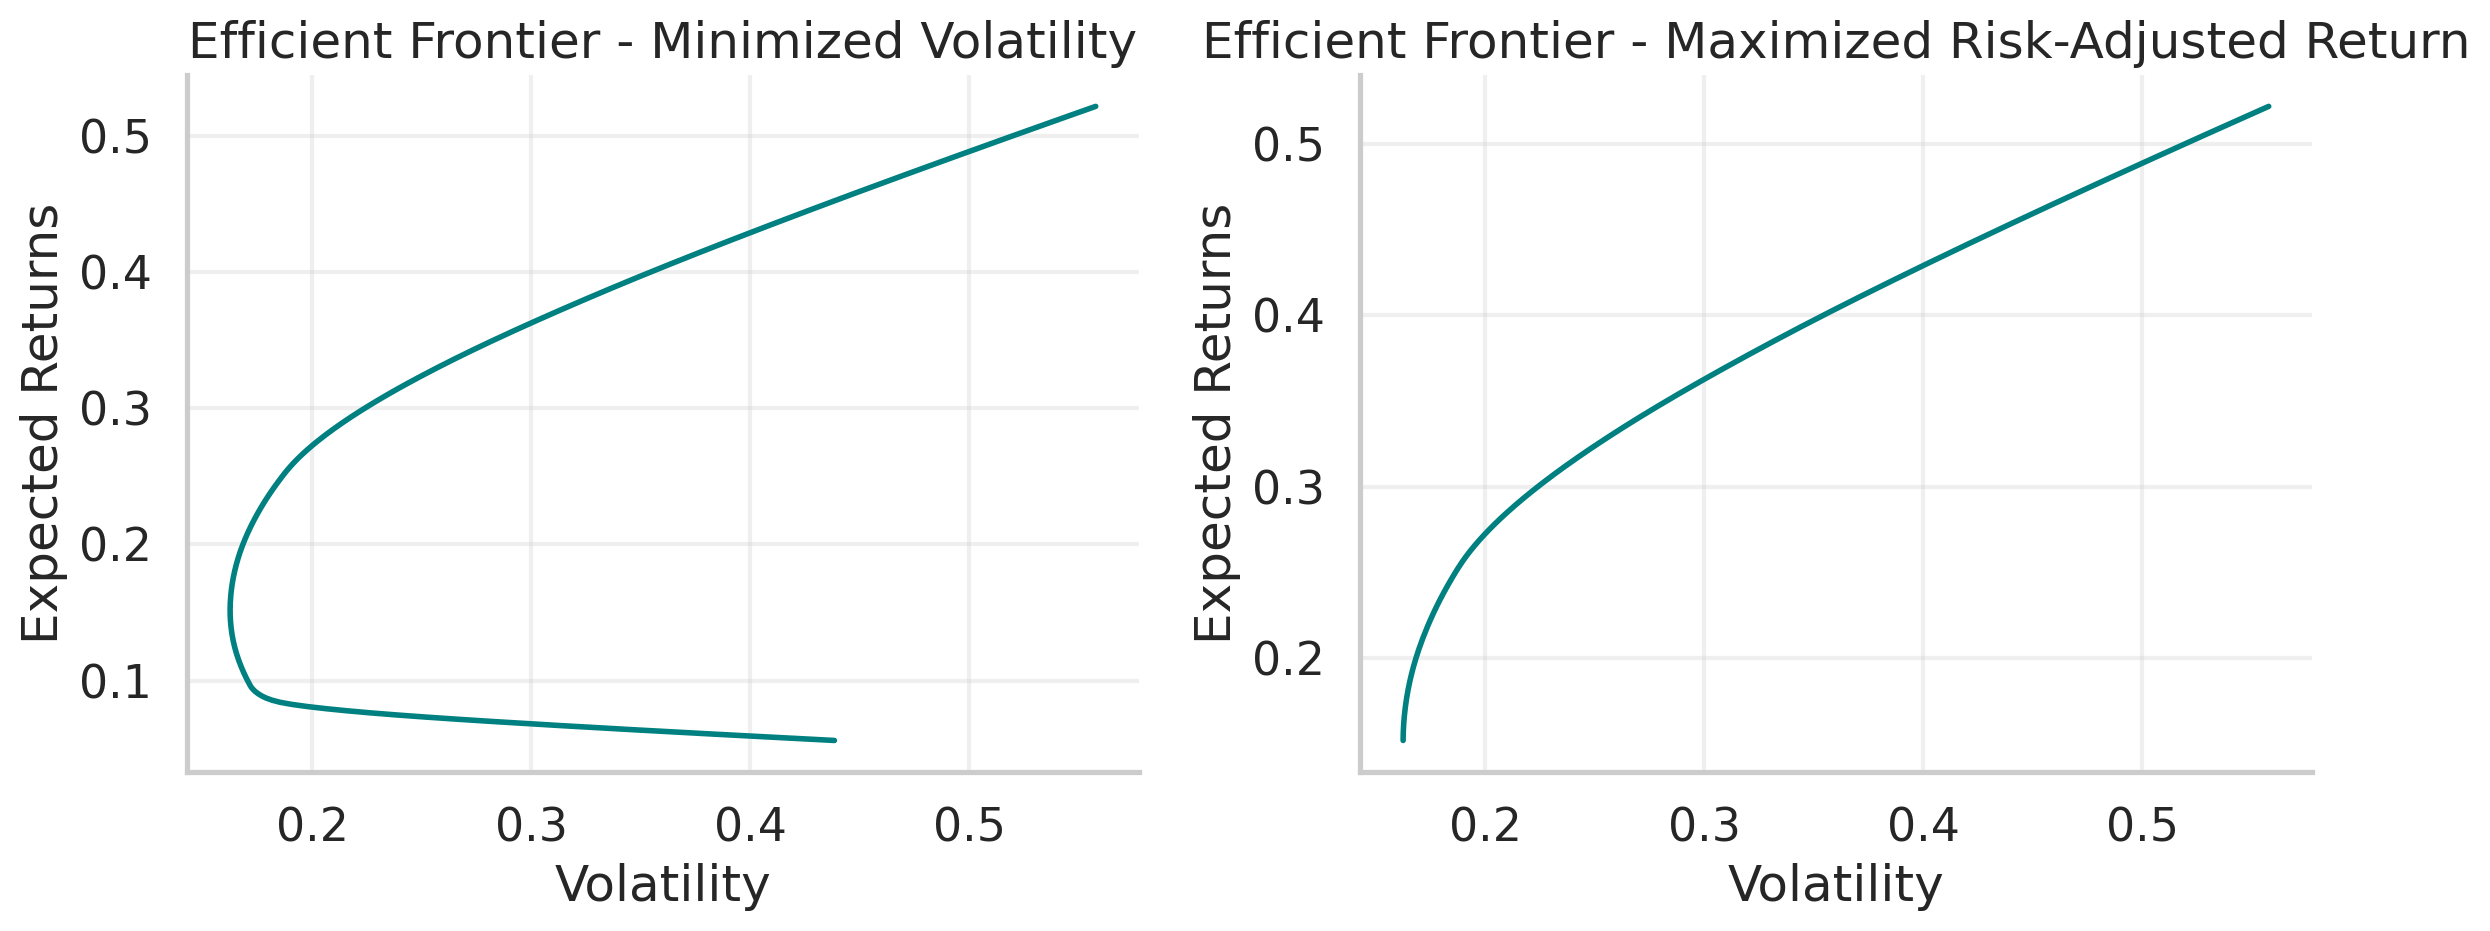

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(risk_mv, ret_mv, color="teal", linewidth=2)
axes[0].set_title("Efficient Frontier - Minimized Volatility")
axes[0].set_xlabel("Volatility")
axes[0].set_ylabel("Expected Returns")
axes[0].grid(True, alpha=0.3)
sns.despine(ax=axes[0])

axes[1].plot(risk_cvxpy, ret_cvxpy, color="teal", linewidth=2)
axes[1].set_title("Efficient Frontier - Maximized Risk-Adjusted Return")
axes[1].set_xlabel("Volatility")
axes[1].set_ylabel("Expected Returns")
axes[1].grid(True, alpha=0.3)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()


The left panel, labeled “Minimized Volatility,” shows the full Markowitz parabola, including both the upper and lower portions of the feasible set. The lower segment represents portfolios that are inefficient because, for the same level of risk, a higher expected return can be achieved by moving to the upper branch. The leftmost point of the curve corresponds to the minimum-variance portfolio, where total volatility is minimized regardless of expected return. Moving away from that point in either direction increases risk, but only the upper branch represents portfolios that are efficient.

The right panel, labeled “Maximized Risk-Adjusted Return,” displays only the upper portion of the frontier the efficient set. This is the region where portfolios offer the highest expected return for each level of volatility. The concave shape reflects diminishing marginal increases in expected return as volatility rises. As risk increases along the frontier, expected return increases as well, but at a decreasing rate. Together, the two panels emphasize the distinction between the full feasible set of portfolios and the subset of portfolios that are mean-variance efficient, reinforcing the principle that rational portfolio choice occurs only along the upper boundary of the frontier.

## 7. Special Portfolios

We identify four key portfolios on the efficient frontier:

| Portfolio | Description |
|-----------|-------------|
| **Min Variance** | Lowest achievable risk (regardless of return) |
| **Max Return** | Corner solution — 100% in the highest-return asset |
| **Min Return** | Corner solution — 100% in the lowest-return asset |
| **Max Sharpe** | Tangency portfolio — maximizes return per unit of risk |


In [ ]:
# ── Minimum Variance ──────────────────────────────────────────────
idx_minvar  = np.argmin(risk_mv)
ret_minvar  = ret_mv[idx_minvar]
risk_minvar = risk_mv[idx_minvar]
w_minvar    = weights_mv[idx_minvar]

# ── Maximum Return ────────────────────────────────────────────────
idx_maxret  = np.argmax(ret_mv)
ret_maxret  = ret_mv[idx_maxret]
risk_maxret = risk_mv[idx_maxret]
w_maxret    = weights_mv[idx_maxret]

# ── Minimum Return ────────────────────────────────────────────────
idx_minret  = np.argmin(ret_mv)
ret_minret  = ret_mv[idx_minret]
risk_minret = risk_mv[idx_minret]
w_minret    = weights_mv[idx_minret]

# ── Maximum Sharpe Ratio ──────────────────────────────────────────
sharpes_mv   = (ret_mv - rf) / risk_mv
idx_maxsr    = np.argmax(sharpes_mv)
ret_maxsr    = ret_mv[idx_maxsr]
risk_maxsr   = risk_mv[idx_maxsr]
w_maxsr      = weights_mv[idx_maxsr]
sharpe_maxsr = sharpes_mv[idx_maxsr]

print("=" * 68)
print("SPECIAL PORTFOLIOS")
print("=" * 68)
print(f"  {'Portfolio':<16} {'Return':>10} {'Risk':>10} {'Sharpe':>10}")
print("-" * 68)
print(f"  {'Min Variance':<16} {ret_minvar*100:>9.2f}% {risk_minvar*100:>9.2f}% {ret_minvar/risk_minvar:>10.4f}")
print(f"  {'Max Return':<16} {ret_maxret*100:>9.2f}% {risk_maxret*100:>9.2f}% {ret_maxret/risk_maxret:>10.4f}")
print(f"  {'Min Return':<16} {ret_minret*100:>9.2f}% {risk_minret*100:>9.2f}% {ret_minret/risk_minret:>10.4f}")
print(f"  {'Max Sharpe':<16} {ret_maxsr*100:>9.2f}% {risk_maxsr*100:>9.2f}% {sharpe_maxsr:>10.4f}")
print("-" * 68)
print(f"  {'1/N Baseline':<16} {ret_eq*100:>9.2f}% {risk_eq*100:>9.2f}% {sharpe_eq:>10.4f}")
print("=" * 68)


SPECIAL PORTFOLIOS
  Portfolio            Return       Risk     Sharpe
--------------------------------------------------------------------
  Min Variance         15.10%     16.24%     0.9300
  Max Return           52.17%     55.76%     0.9356
  Min Return            5.60%     43.83%     0.1278
  Max Sharpe           27.25%     19.98%     1.3641
--------------------------------------------------------------------
  1/N Baseline         18.87%     20.72%     0.9109


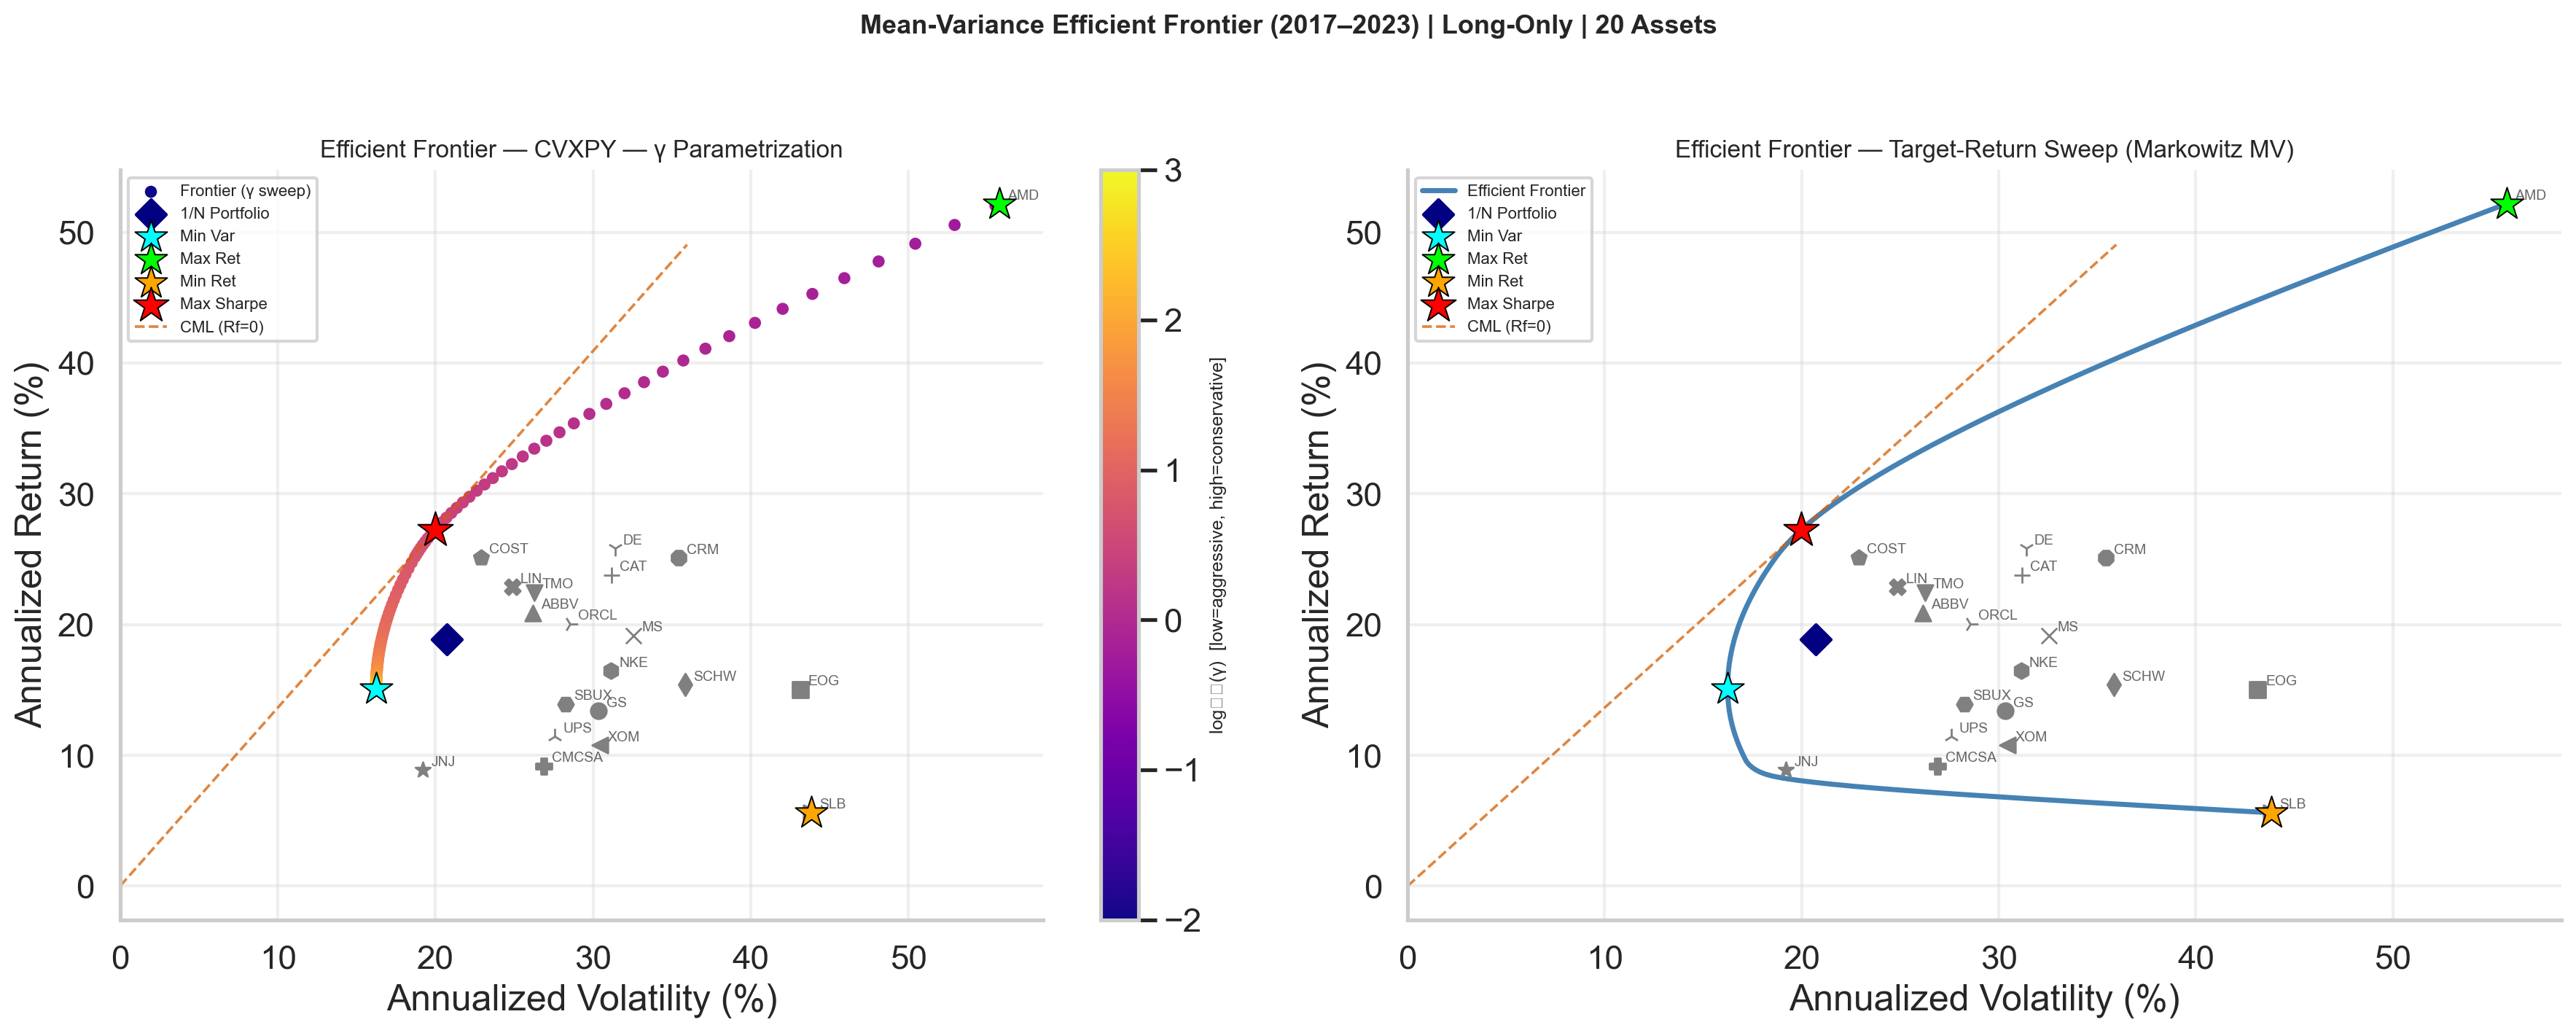

✓ Saved as efficient_frontier.png


In [ ]:
specials = {
    "Min Var":    (risk_minvar,  ret_minvar,  "cyan",   "*", 280),
    "Max Ret":    (risk_maxret,  ret_maxret,  "lime",   "*", 280),
    "Min Ret":    (risk_minret,  ret_minret,  "orange", "*", 280),
    "Max Sharpe": (risk_maxsr,   ret_maxsr,   "red",    "*", 330),
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

configs = [
    ("CVXPY \u2014 \u03b3 Parametrization", "cvxpy"),
    ("Target-Return Sweep (Markowitz MV)", "mv"),
]

for ax, (title_sfx, method) in zip(axes, configs):

    if method == "cvxpy":
        sc = ax.scatter(risk_cvxpy * 100, ret_cvxpy * 100,
                        c=np.log10(gammas[:len(ret_cvxpy)]),
                        cmap="plasma", s=20, zorder=2,
                        label="Frontier (\u03b3 sweep)")
        cbar = fig.colorbar(sc, ax=ax)
        cbar.set_label("log\u2081\u2080(\u03b3)  [low=aggressive, high=conservative]",
                        fontsize=9)
    else:
        ax.plot(risk_mv * 100, ret_mv * 100,
                color="steelblue", linewidth=2.5,
                label="Efficient Frontier", zorder=2)

    # Individual assets
    for i, tk in enumerate(ASSETS):
        ax.scatter(vols_ind[i]*100, mu_val[i]*100,
                   marker=MARKERS[i], s=60, color="gray",
                   linewidths=1.0, zorder=3)
        ax.annotate(tk, (vols_ind[i]*100, mu_val[i]*100),
                    textcoords="offset points", xytext=(4, 2),
                    fontsize=7, color="dimgray")

    # 1/N portfolio
    ax.scatter(risk_eq*100, ret_eq*100,
               marker="D", color="navy", s=110, zorder=5,
               label="1/N Portfolio")

    # Special portfolios
    for label, (r, ret, c, mk, ms) in specials.items():
        ax.scatter(r*100, ret*100, marker=mk, color=c,
                   edgecolors="black", linewidths=0.7,
                   s=ms, zorder=6, label=label)

    # Capital Market Line
    x_cml = np.linspace(0, risk_maxsr * 1.8 * 100, 100)
    y_cml = rf * 100 + sharpe_maxsr * x_cml
    ax.plot(x_cml, y_cml, "r--", linewidth=1.3, alpha=0.75, label="CML (Rf=0)")

    ax.set_title(f"Efficient Frontier \u2014 {title_sfx}", fontsize=12)
    ax.set_xlabel("Annualized Volatility (%)")
    ax.set_ylabel("Annualized Return (%)")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)
    sns.despine(ax=ax)

plt.suptitle(
    "Mean-Variance Efficient Frontier (2017\u20132023) | Long-Only | 20 Assets",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("efficient_frontier.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2713 Saved as efficient_frontier.png")


This figure presents the mean-variance efficient frontier for the 20-asset long-only portfolio over the period 2017–2023, constructed using two different approaches. The left panel shows the frontier obtained through CVXPY using a γ-parameterization (risk-aversion sweep), while the right panel shows the frontier derived from a target-return sweep under the classical Markowitz formulation. In both panels, the horizontal axis represents annualized volatility and the vertical axis represents annualized expected return.

In the left panel, the colored points trace the efficient frontier as the risk-aversion parameter γ varies. Lower γ values place greater emphasis on maximizing return, producing portfolios toward the upper-right region of the curve with higher volatility and higher expected return. Higher γ values emphasize variance minimization, shifting portfolios toward the lower-left region where volatility is reduced. The color gradient reflects this transition in risk preference. The special portfolios are highlighted: the minimum-variance portfolio appears at the leftmost point of the frontier, the maximum-return portfolio lies at the far right with the highest expected return and highest volatility, the minimum-return portfolio appears at the lower end of the feasible region, and the maximum Sharpe portfolio lies at the tangency point where the slope of the capital market line is greatest. The dashed line represents the capital market line (CML), which is tangent to the frontier at the maximum Sharpe portfolio, indicating the portfolio that maximizes risk-adjusted return.

The right panel reconstructs the frontier using a target-return constraint, solving for the minimum volatility portfolio at each required expected return level. The resulting curve traces the same efficient set, confirming consistency between the γ-parameterization and the traditional Markowitz optimization. The lower branch of the parabola (visible in the right panel) represents inefficient portfolios, as they deliver lower return for the same risk compared to the upper branch. Only the upper boundary constitutes the efficient frontier.

The individual asset points plotted in grey lie mostly below the frontier, reinforcing the principle of diversification: combinations of assets dominate individual securities in terms of risk-return trade-off. The separation between single assets and the frontier visually demonstrates the improvement achieved through optimal portfolio construction.

Overall, the figure confirms the theoretical predictions of mean-variance portfolio theory: the feasible set forms a parabolic region in risk-return space, the efficient frontier corresponds to its upper boundary, portfolio composition changes systematically with risk aversion, and diversification allows investors to achieve superior risk-return combinations relative to holding individual assets.

## 8. Portfolio Weights Table

Per the assignment requirement, the table below shows the **weight of each stock
in each of the four special portfolios**, along with summary performance metrics.


In [ ]:
labels_sp  = ["Min Variance", "Max Return", "Min Return", "Max Sharpe"]
weights_sp = [w_minvar,       w_maxret,     w_minret,    w_maxsr   ]

# Build DataFrame — zero out negligible weights (< 0.01%)
weights_sp_df = pd.DataFrame(
    {lbl: np.where(np.abs(w) < 1e-4, 0.0, w)
     for lbl, w in zip(labels_sp, weights_sp)},
    index=ASSETS
) * 100   # express as %

weights_sp_df.index.name = "Ticker"

# Performance summary rows
summary_sp = pd.DataFrame({
    "Min Variance": [ret_minvar*100, risk_minvar*100, ret_minvar/risk_minvar],
    "Max Return":   [ret_maxret*100, risk_maxret*100, ret_maxret/risk_maxret],
    "Min Return":   [ret_minret*100, risk_minret*100, ret_minret/risk_minret],
    "Max Sharpe":   [ret_maxsr*100,  risk_maxsr*100,  sharpe_maxsr          ],
}, index=["Ann. Return (%)", "Ann. Std Dev (%)", "Sharpe Ratio"])

full_table = pd.concat([weights_sp_df, summary_sp])

pd.set_option("display.float_format", "{:.2f}".format)
print("=" * 68)
print("PORTFOLIO WEIGHTS (%)  &  PERFORMANCE METRICS")
print("=" * 68)
print(full_table.to_string())
print("=" * 68)


PORTFOLIO WEIGHTS (%)  &  PERFORMANCE METRICS
                  Min Variance  Max Return  Min Return  Max Sharpe
GS                        0.00        0.00        0.00        0.00
MS                        0.00        0.00        0.00        0.00
SCHW                      0.00        0.00        0.00        0.00
JNJ                      38.73        0.00        0.00        0.00
ABBV                     10.04        0.00        0.00       19.27
TMO                       5.99        0.00        0.00        5.92
XOM                       8.45        0.00        0.00        0.00
SLB                       0.00        0.00      100.00        0.00
EOG                       0.00        0.00        0.00        0.00
COST                     19.51        0.00        0.00       40.63
NKE                       0.00        0.00        0.00        0.00
SBUX                      1.66        0.00        0.00        0.00
CAT                       0.00        0.00        0.00        1.12
DE              

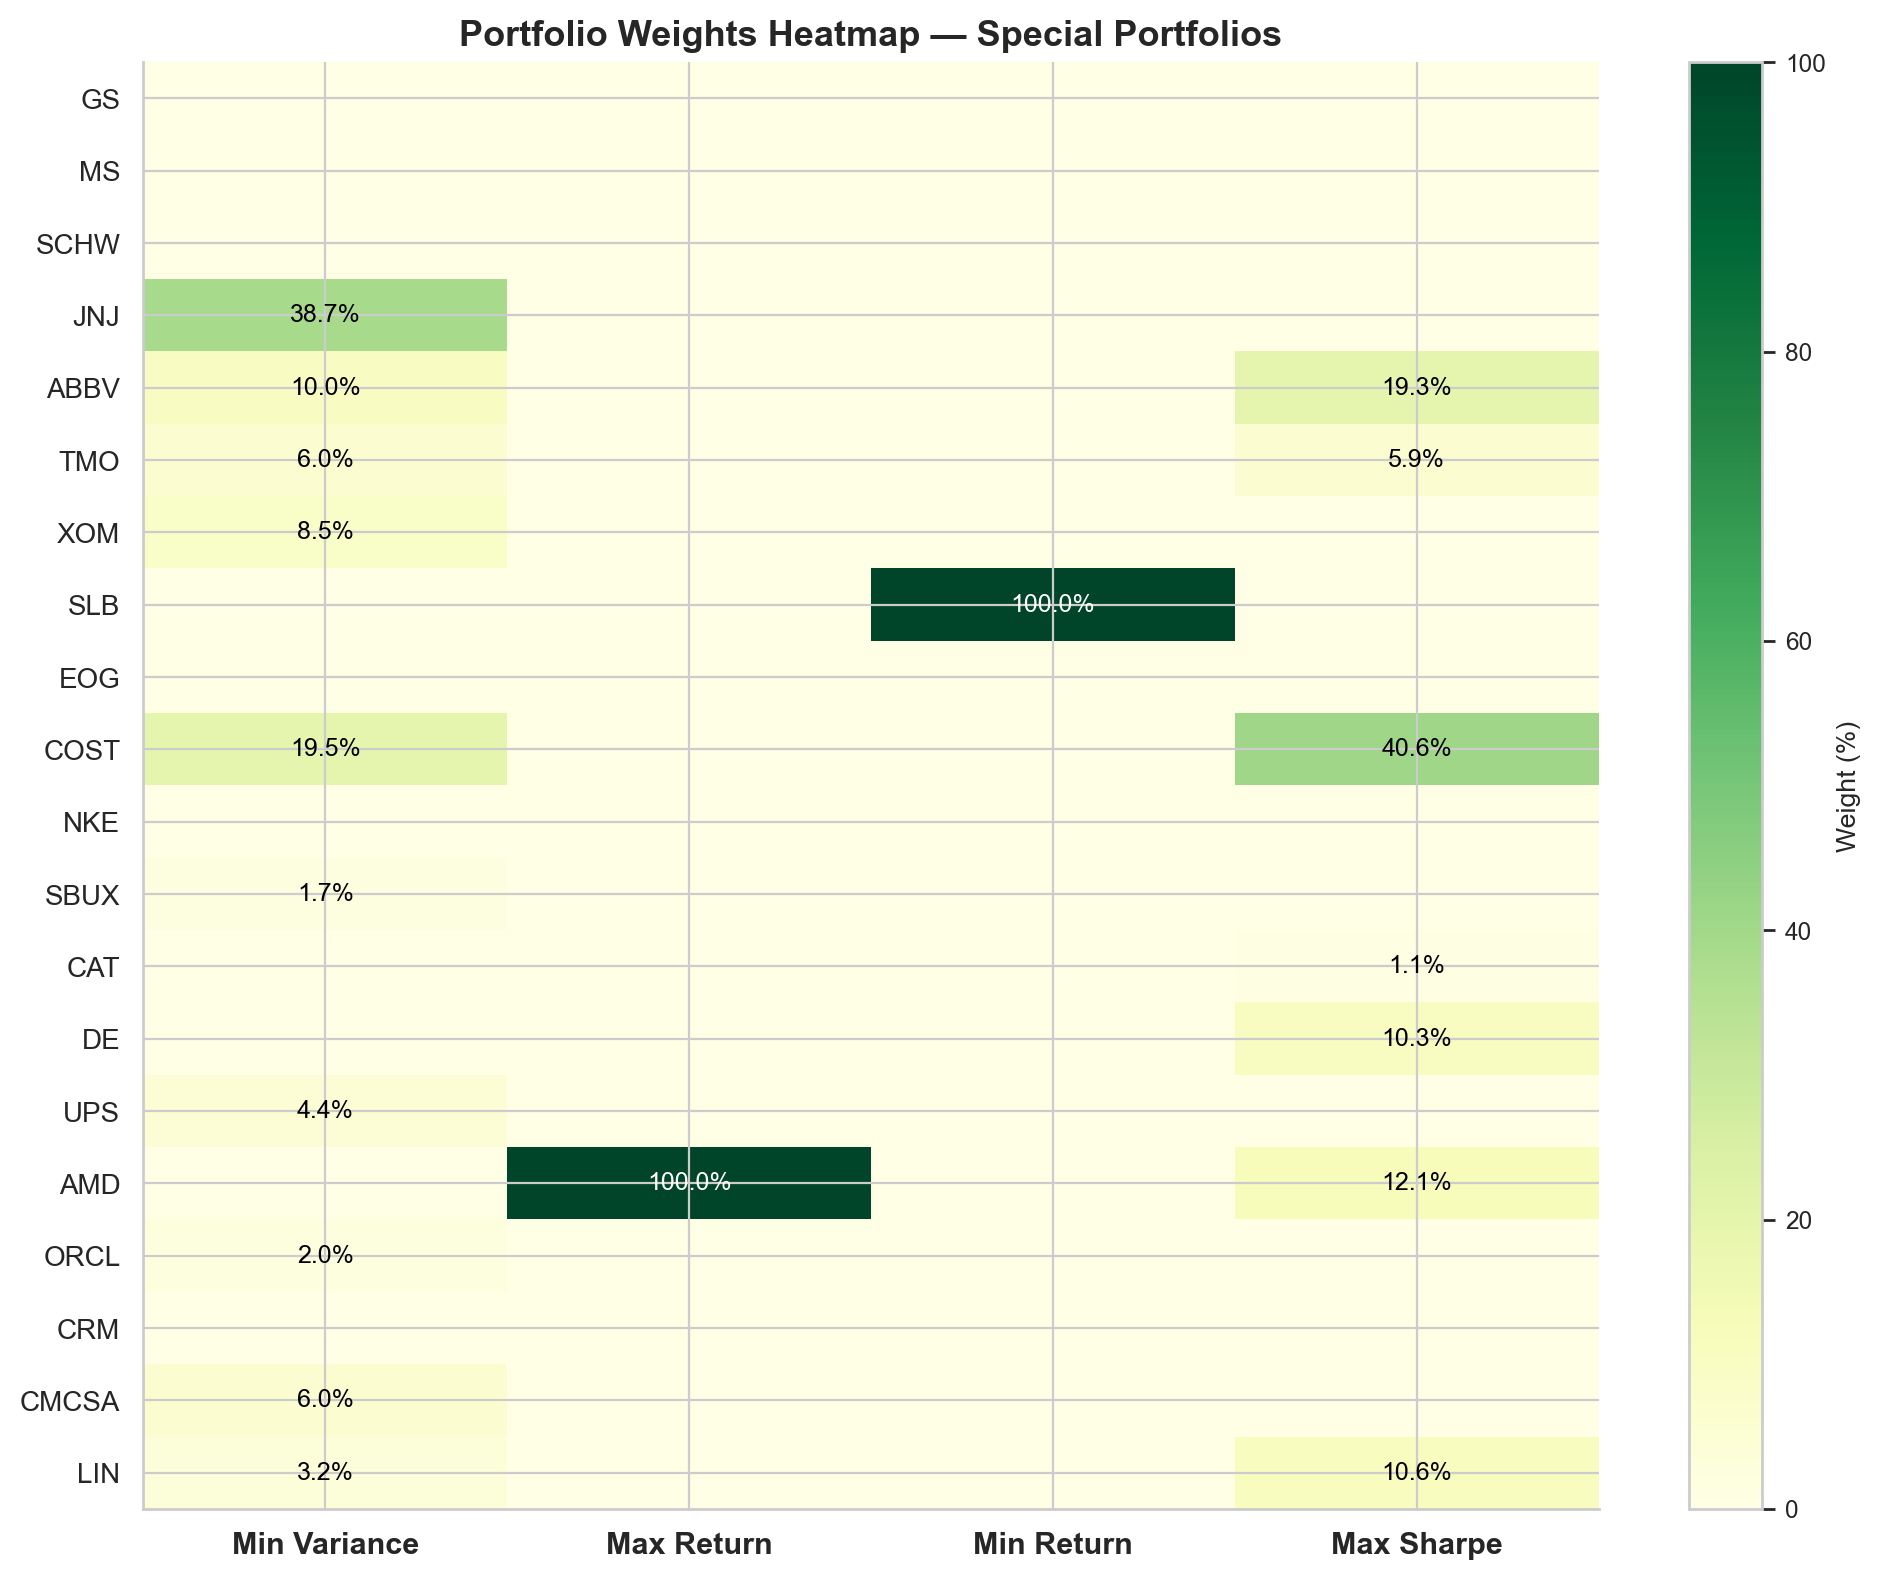

✓ Saved as weights_heatmap.png


In [ ]:
with sns.plotting_context("paper"):
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(weights_sp_df.values, cmap="YlGn", aspect="auto",
                   vmin=0, vmax=weights_sp_df.values.max())

    ax.set_xticks(range(len(labels_sp)))
    ax.set_xticklabels(labels_sp, fontsize=11, fontweight="bold")
    ax.set_yticks(range(n_assets))
    ax.set_yticklabels(ASSETS, fontsize=10)

    for i in range(n_assets):
        for j in range(len(labels_sp)):
            val = weights_sp_df.iloc[i, j]
            if val > 0.1:
                ax.text(j, i, f"{val:.1f}%",
                        ha="center", va="center", fontsize=9,
                        color="black" if val < 50 else "white")

    fig.colorbar(im, ax=ax, label="Weight (%)")
    ax.set_title("Portfolio Weights Heatmap \u2014 Special Portfolios",
                 fontsize=13, fontweight="bold")
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig("weights_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\u2713 Saved as weights_heatmap.png")


This heatmap presents the portfolio weights of the four special portfolios identified on the efficient frontier: the minimum-variance portfolio, the maximum-return portfolio, the minimum-return portfolio, and the maximum Sharpe portfolio. Each row corresponds to one of the 20 assets, and each column represents one of these optimized portfolios. The intensity of the color reflects the magnitude of the allocation, with darker shades indicating higher weights.

The minimum-variance portfolio displays a relatively diversified structure, with capital distributed across several assets rather than concentrated in a single position. This reflects the objective of minimizing overall portfolio volatility, which typically requires combining assets in a way that reduces total variance through diversification. In contrast, the maximum-return portfolio is fully concentrated in a single asset, as indicated by the 100% allocation. This outcome is consistent with the optimization objective: when only expected return is maximized under long-only constraints, the solution allocates all capital to the asset with the highest estimated return.

Similarly, the minimum-return portfolio is also fully concentrated in one asset, specifically the asset with the lowest expected return. This is a mechanical result of the optimization problem when minimizing expected return subject to the same constraints. The maximum Sharpe portfolio, which maximizes risk-adjusted return, exhibits a more balanced allocation compared to the extreme cases but remains more selective than the minimum-variance portfolio. It allocates higher weights to assets that contribute favorably to the return-to-risk ratio, while assigning smaller or zero weights to less efficient assets.

## 9. Leverage and Short Selling

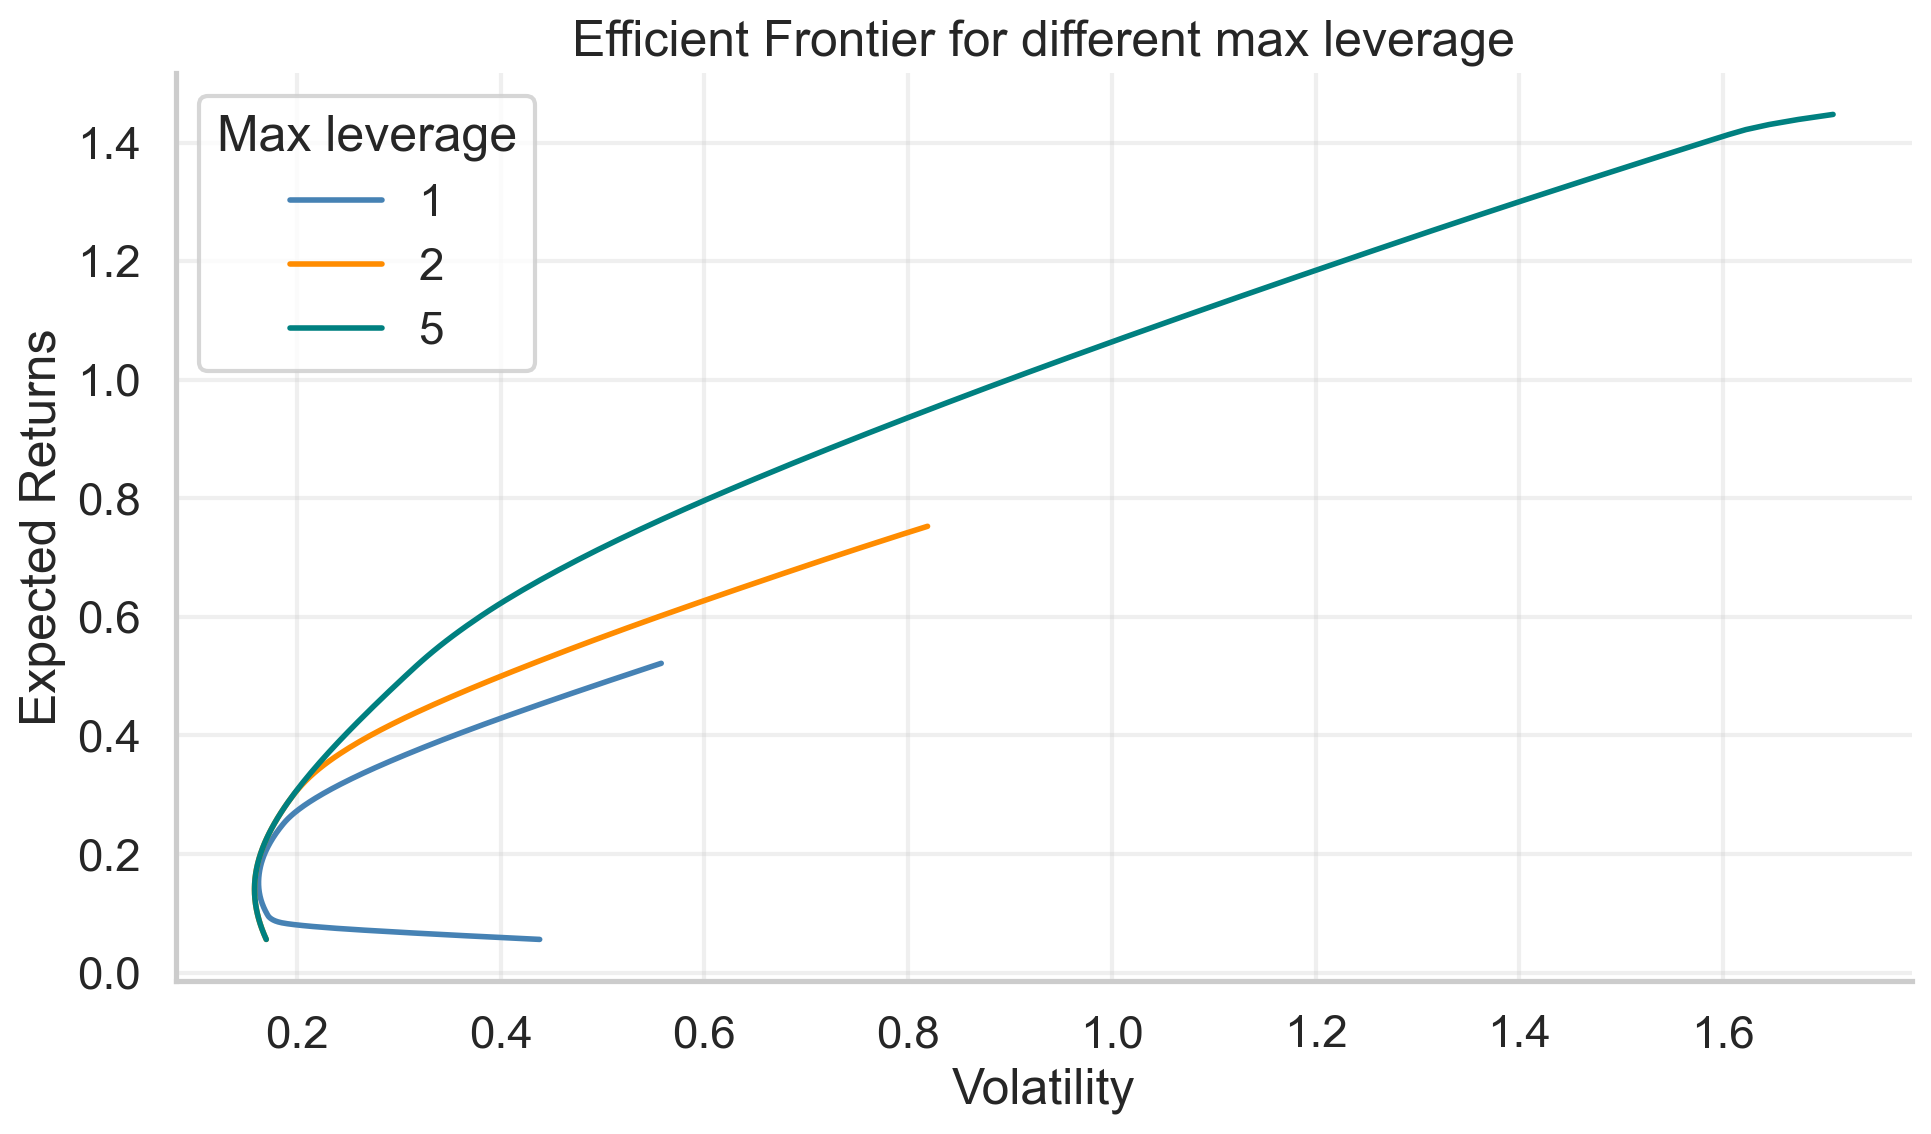

In [ ]:
leverage_levels = [1, 2, 5]
colors_lev      = ["steelblue", "darkorange", "teal"]

fig, ax = plt.subplots(figsize=(10, 6))

for L, col in zip(leverage_levels, colors_lev):
    ret_l, risk_l = [], []

    w_lev   = cp.Variable(n_assets)
    tgt_lev = cp.Parameter()

    if L == 1:
        constraints = [mu_val @ w_lev == tgt_lev,
                       cp.sum(w_lev) == 1,
                       w_lev >= 0]
    else:
        constraints = [mu_val @ w_lev == tgt_lev,
                       cp.sum(w_lev) == 1,
                       cp.norm1(w_lev) <= L]

    prob = cp.Problem(cp.Minimize(cp.quad_form(w_lev, cov_val)), constraints)

    for tr in np.linspace(mu_val.min(), mu_val.max() * L, 300):
        tgt_lev.value = tr
        prob.solve(solver=cp.OSQP, eps_abs=1e-8, eps_rel=1e-8)
        if prob.status in ["optimal", "optimal_inaccurate"]:
            wv = w_lev.value
            ret_l.append(float(mu_val @ wv))
            risk_l.append(float(np.sqrt(wv @ cov_val @ wv)))

    ax.plot(risk_l, ret_l, color=col, linewidth=2, label=str(L))

ax.set_title("Efficient Frontier for different max leverage")
ax.set_xlabel("Volatility")
ax.set_ylabel("Expected Returns")
ax.legend(title="Max leverage")
ax.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()


This figure shows the efficient frontier under different maximum leverage constraints, where leverage is controlled through the upper bound on the sum of absolute portfolio weights. The three curves correspond to maximum leverage levels of 1, 2, and 5. A leverage level of 1 represents the long-only case, where total weights sum to one and no short selling is allowed. Higher leverage levels permit larger long and short positions, expanding the feasible investment set.

The curve for leverage equal to 1 forms the most restricted frontier, reflecting the limited flexibility of long-only portfolios. When leverage increases to 2, the efficient frontier shifts outward, allowing for portfolios with both higher expected return and higher volatility. With leverage equal to 5, the frontier expands even further, significantly extending the attainable risk-return combinations. This outward shift illustrates that allowing short selling and greater capital exposure increases the range of achievable expected returns for any given level of risk.

As leverage increases, both expected return and volatility rise more rapidly along the frontier, reflecting the magnified impact of asset exposures. The curvature remains consistent with mean-variance theory, but the scale expands as constraints are relaxed. Overall, the chart demonstrates that leverage enlarges the feasible set of portfolios, pushing the efficient frontier outward and allowing more extreme risk-return combinations compared to the constrained long-only case.

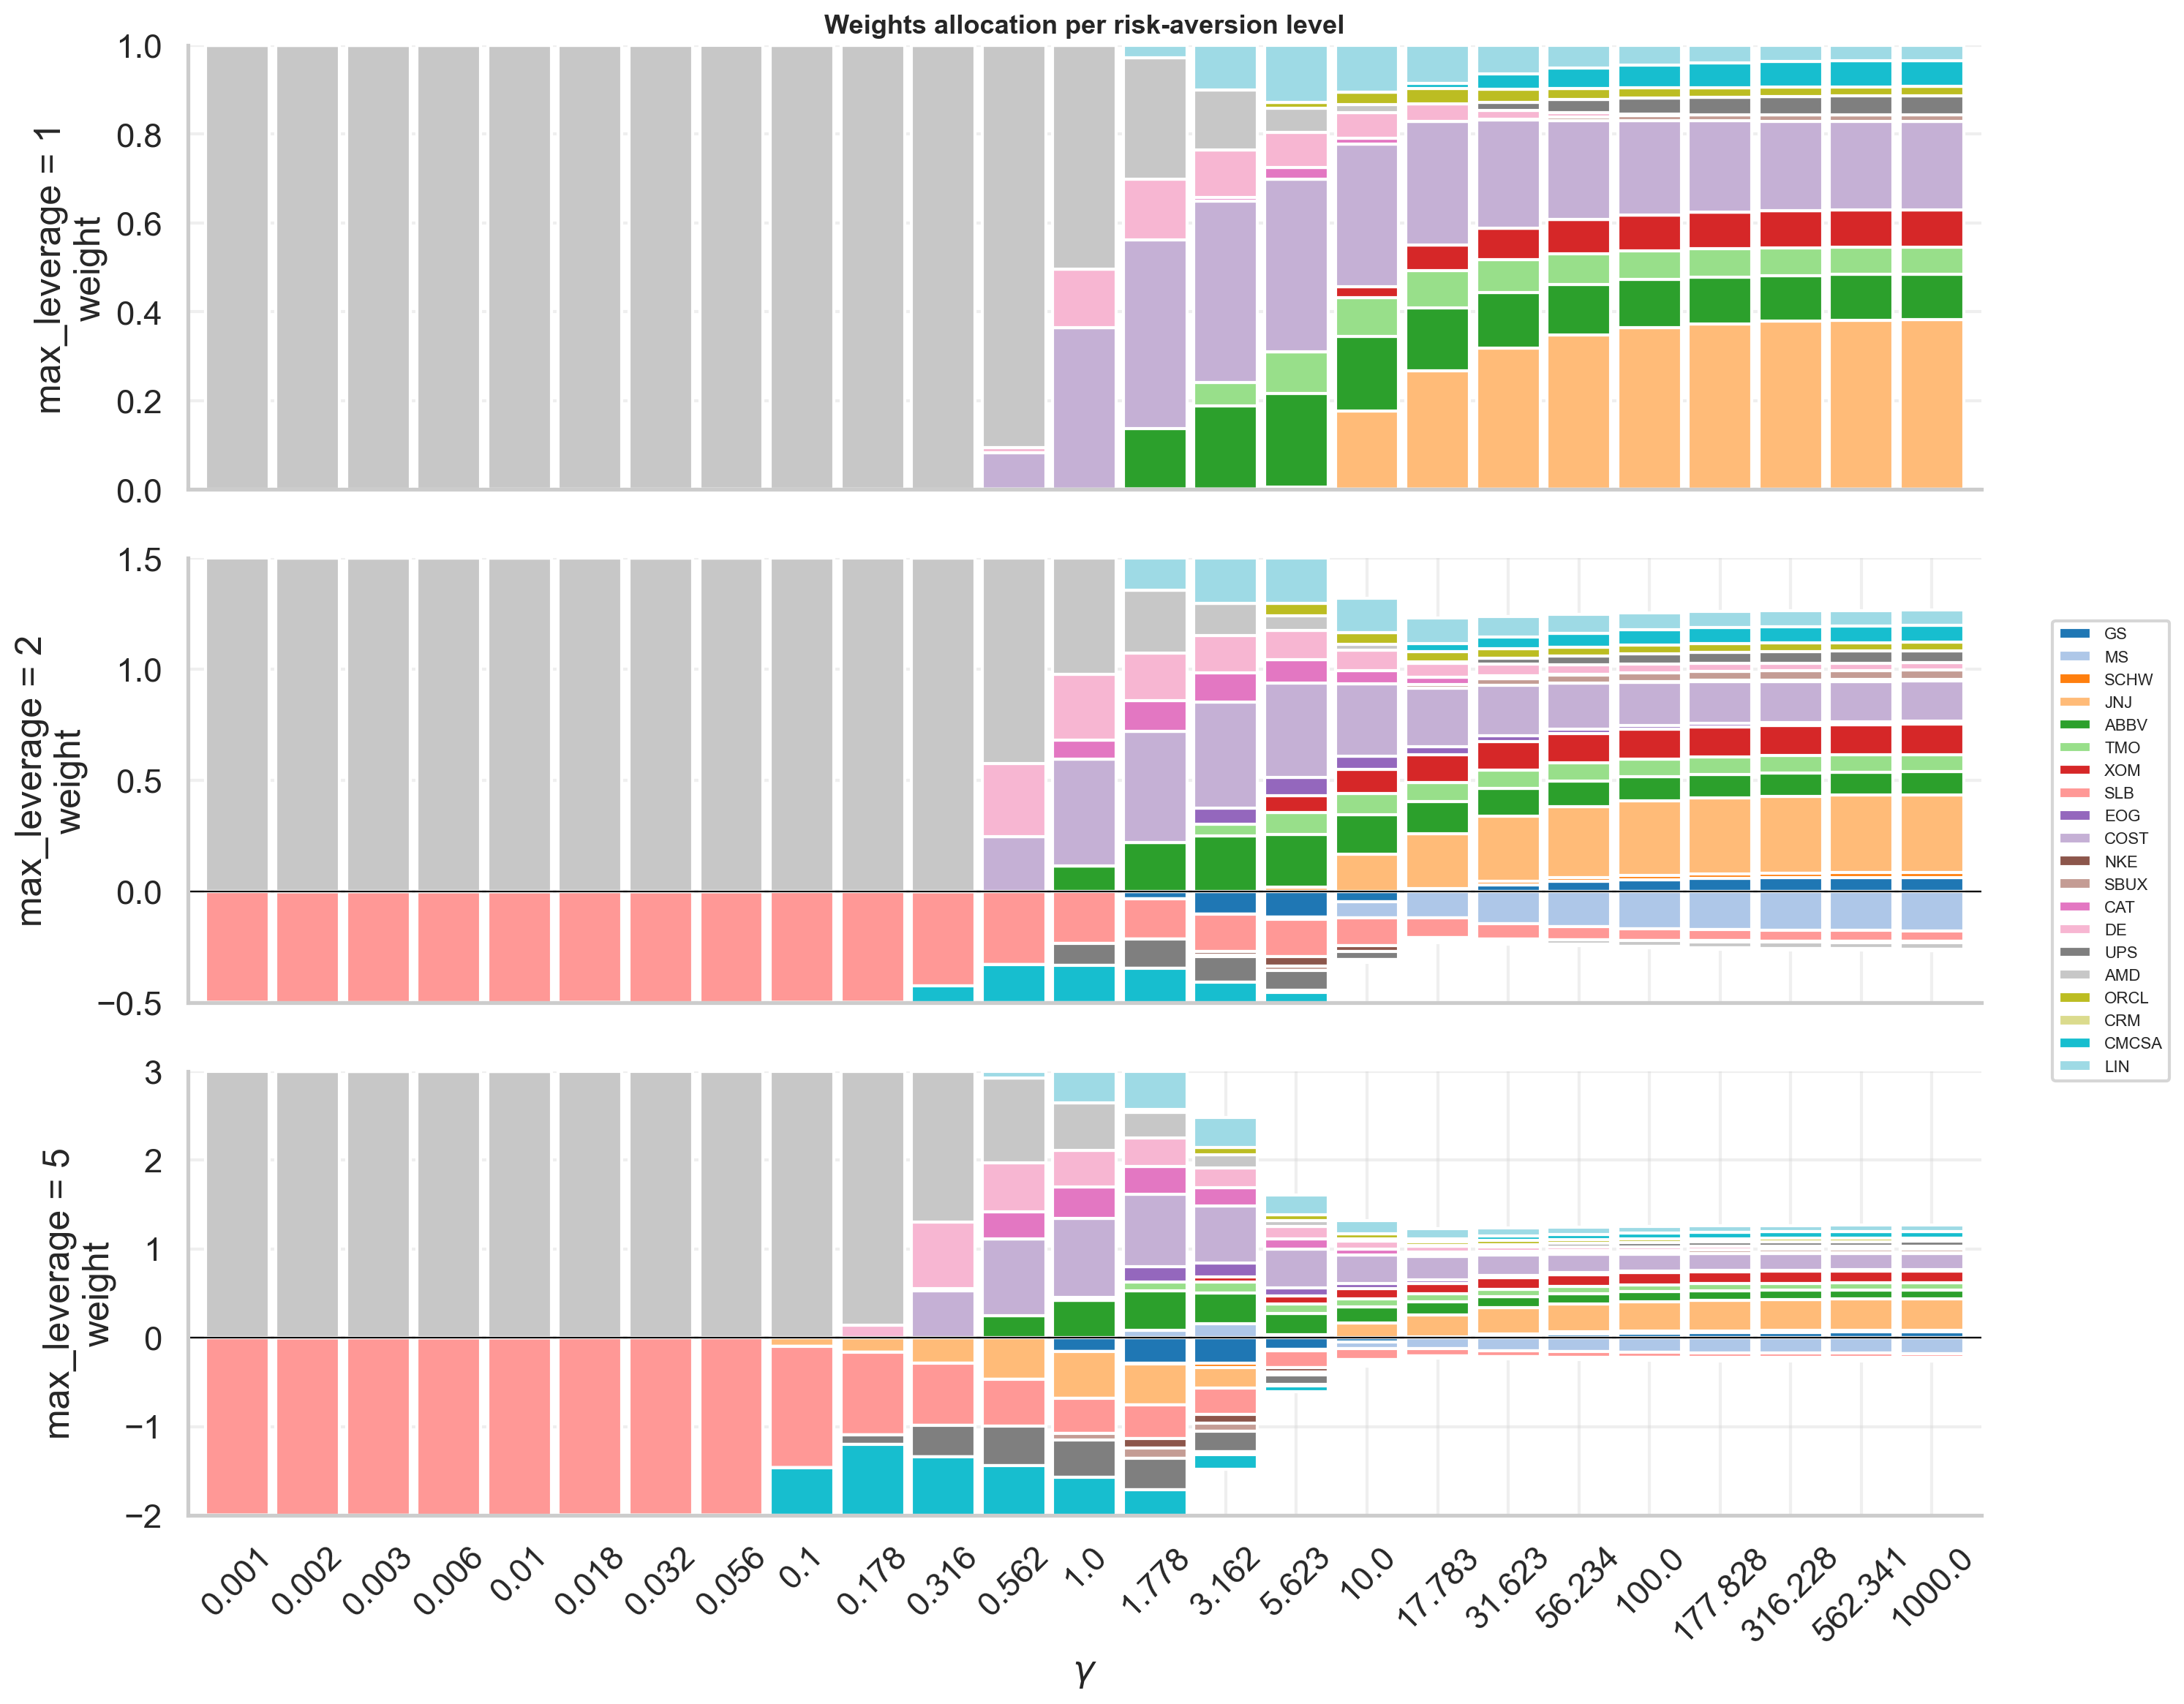

In [ ]:
leverage_levels = [1, 2, 5]
gammas_lev = np.logspace(-3, 3, 25)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, L in zip(axes, leverage_levels):
    weights_lev = []

    w_l = cp.Variable(n_assets)
    g_l = cp.Parameter(nonneg=True)

    if L == 1:
        con = [cp.sum(w_l) == 1, w_l >= 0]
    else:
        con = [cp.sum(w_l) == 1, cp.norm1(w_l) <= L]

    prob_l = cp.Problem(
        cp.Maximize(mu_val @ w_l - g_l * cp.quad_form(w_l, cov_val)), con
    )

    for g in gammas_lev:
        g_l.value = g
        prob_l.solve(solver=cp.OSQP, eps_abs=1e-8, eps_rel=1e-8)
        weights_lev.append(
            w_l.value if prob_l.status in ["optimal", "optimal_inaccurate"]
            else np.zeros(n_assets)
        )

    weights_lev_df = pd.DataFrame(
        weights_lev, columns=ASSETS,
        index=np.round(gammas_lev, 3)
    )

    weights_lev_df.plot(kind="bar", stacked=True, ax=ax,
                        colormap="tab20", width=0.9, legend=False)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel(f"max_leverage = {L}\nweight")
    ax.grid(True, alpha=0.3)
    sns.despine(ax=ax)

axes[0].set_title("Weights allocation per risk-aversion level",
                  fontsize=13, fontweight="bold")
axes[-1].set_xlabel(r"$\gamma$")
axes[-1].tick_params(axis="x", rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 0.5),
           loc="center left", fontsize=8)

plt.tight_layout()
plt.show()


This figure shows how portfolio weights evolve across different levels of risk aversion (γ) under three leverage constraints: max leverage = 1 (long-only), 2, and 5. Each panel represents a different leverage limit, and within each panel, the stacked bars display how total portfolio weight is distributed across assets as γ increases from left (low risk aversion) to right (high risk aversion). Positive weights appear above zero, while negative weights (short positions) appear below zero in the leveraged cases.

In the top panel (max leverage = 1), allocations remain non-negative, reflecting the long-only constraint. For very low γ values, the portfolio is highly concentrated, allocating nearly all capital to a single asset that maximizes expected return. As γ increases, the portfolio becomes more diversified, with weights spreading across multiple assets. At higher γ levels, the structure stabilizes into a more balanced allocation consistent with variance minimization.

In the middle panel (max leverage = 2), the feasible set expands and negative weights begin to appear, indicating short positions. For low γ values, the portfolio exhibits more extreme allocations, including substantial long and short exposures. As γ rises, the magnitude of both long and short positions gradually decreases, and the allocation becomes more stable and diversified, though still more flexible than in the long-only case.

In the bottom panel (max leverage = 5), the weight magnitudes become significantly larger for low γ values, reflecting the optimizer’s ability to take aggressive leveraged positions. Large positive and negative exposures appear simultaneously, demonstrating how relaxing leverage constraints allows the model to amplify both expected return and risk. As γ increases, these extreme exposures contract and the portfolio gradually transitions toward a more balanced allocation.

Overall, the figure illustrates how portfolio composition is jointly determined by risk aversion and leverage constraints. Lower γ values lead to concentrated or aggressive allocations, especially when leverage is permitted, while higher γ values promote diversification and reduced exposure. Increasing leverage expands the feasible weight space, resulting in larger and more extreme positions at lower levels of risk aversion.

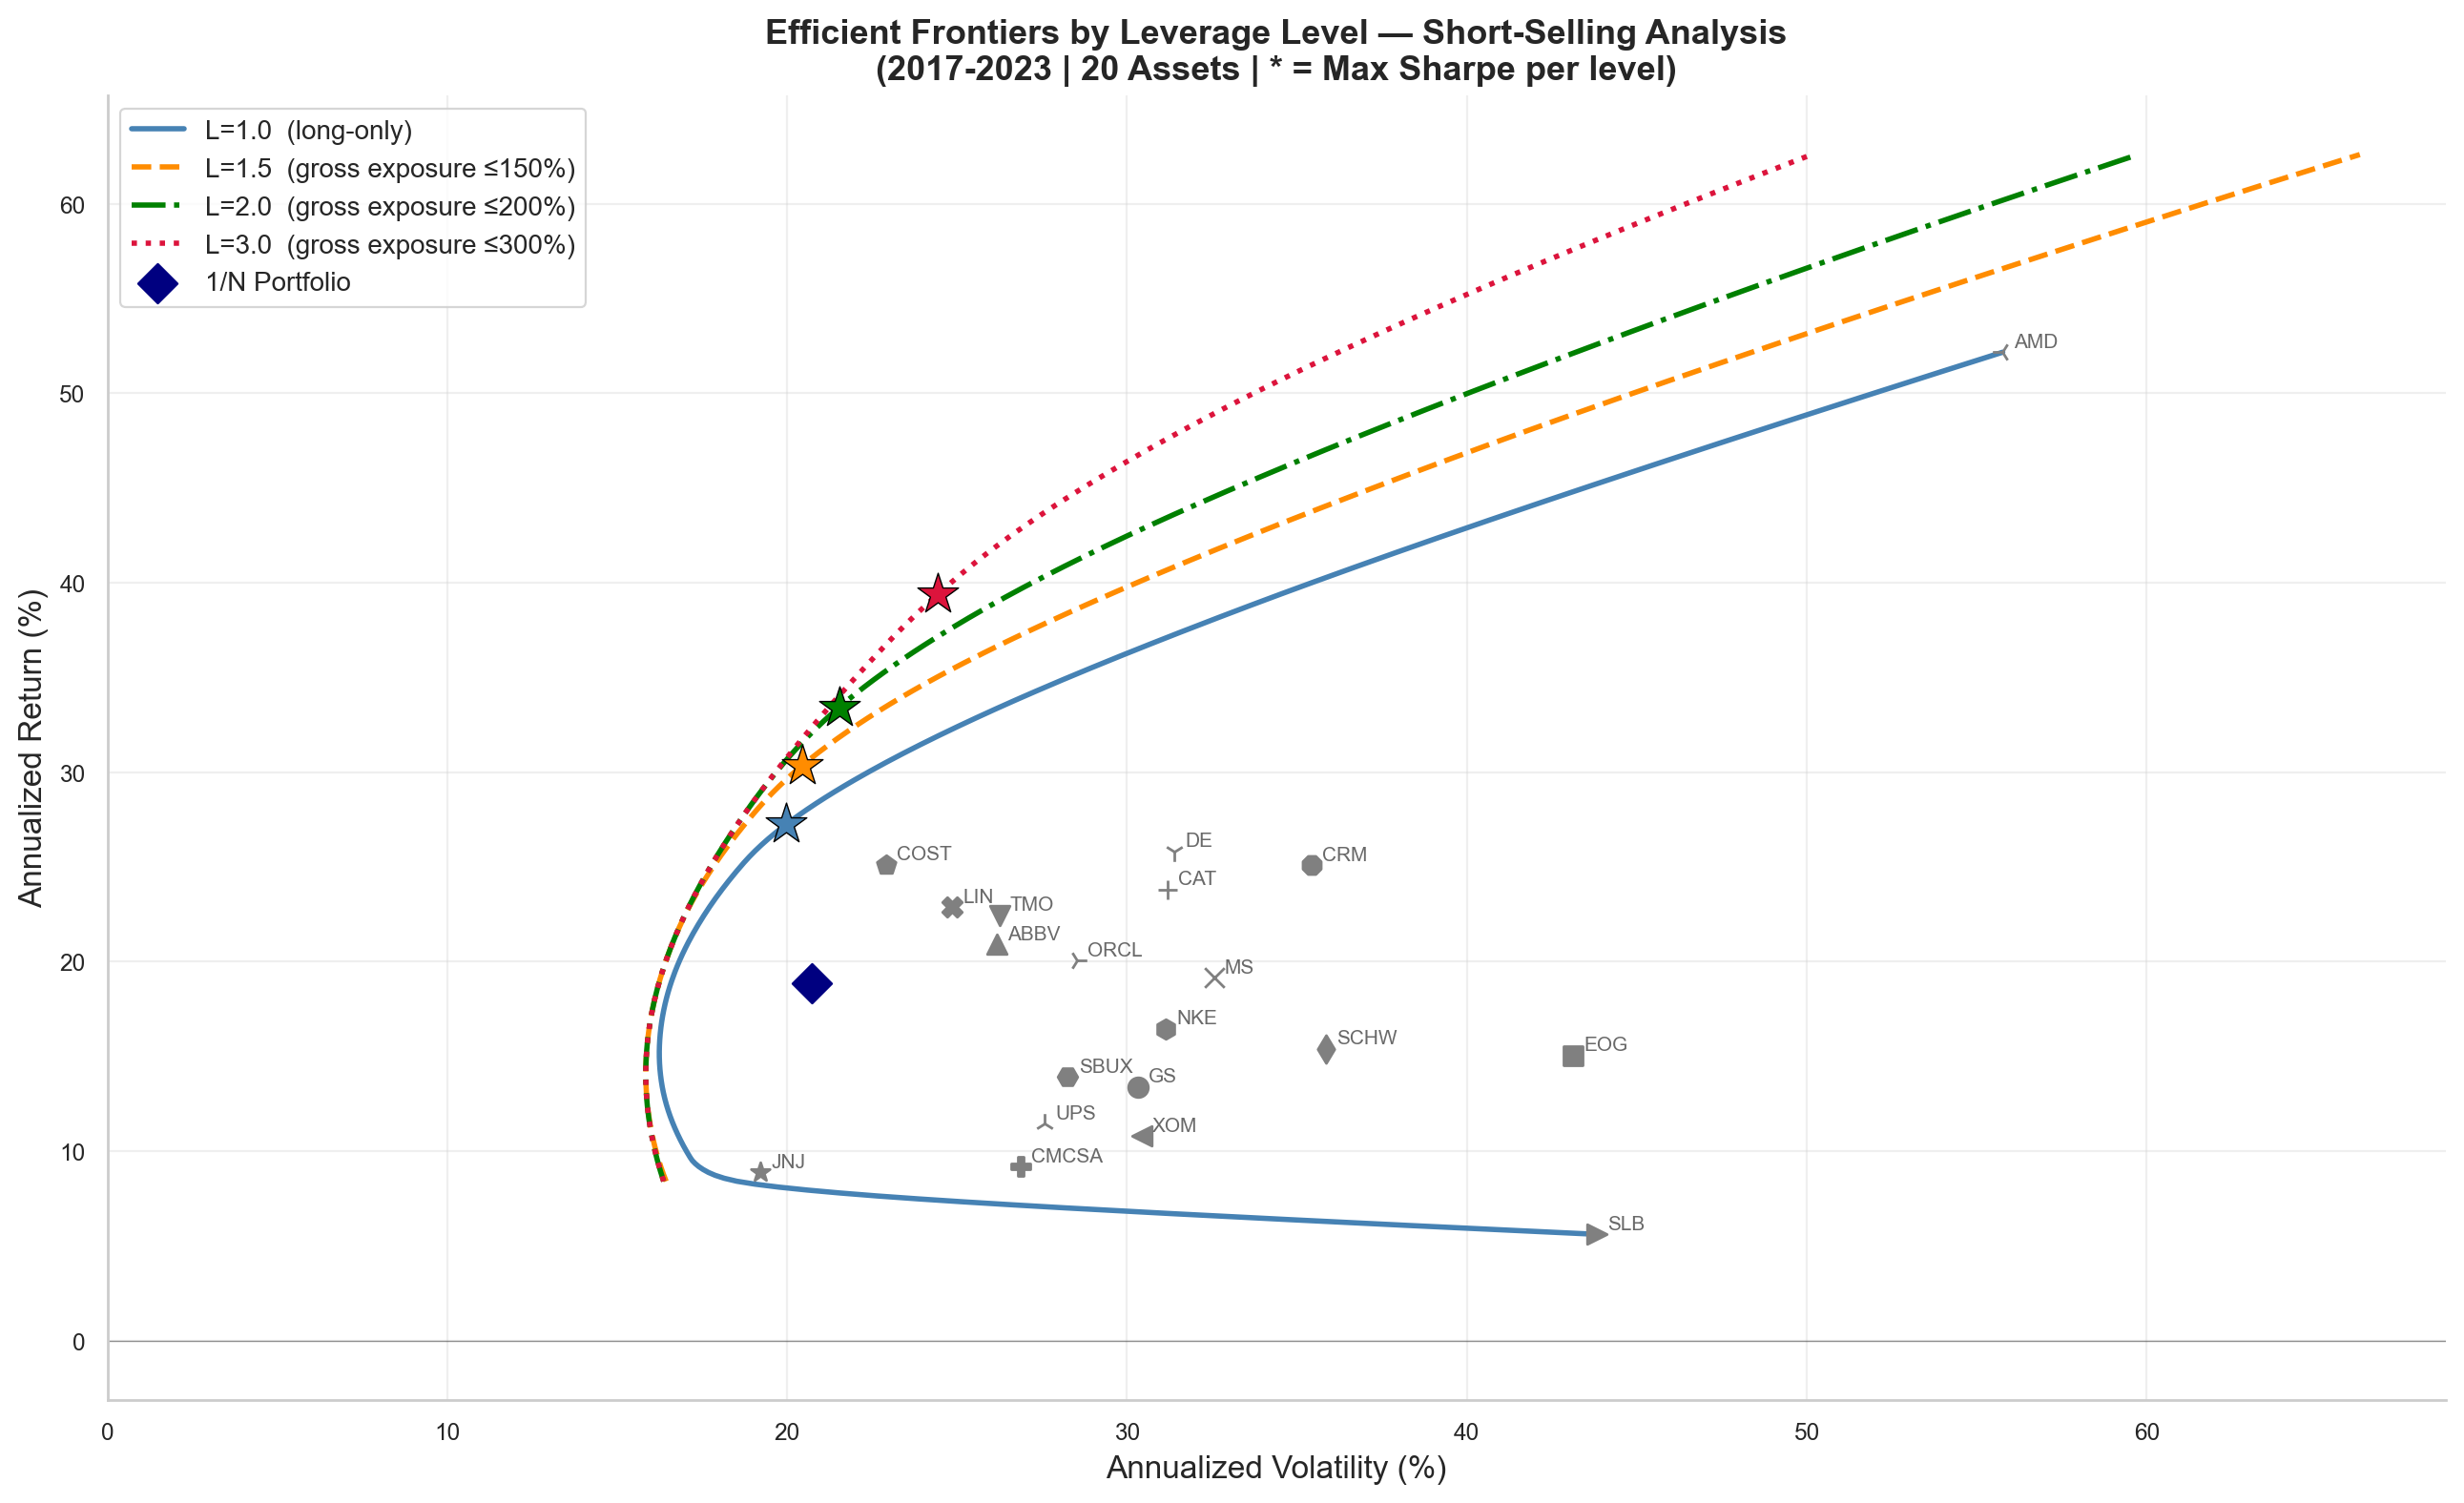

✓ Saved as efficient_frontier_leverage.png

=== Max Sharpe Portfolio per Leverage Level ===
    L |     Return |       Risk |     Sharpe |     Δ vs L=1
----------------------------------------------------------
  1.0 |     27.25% |     19.98% |     1.3641 |     +0.0000
  1.5 |     30.34% |     20.43% |     1.4848 |     +0.1207
  2.0 |     33.42% |     21.53% |     1.5525 |     +0.1884
  3.0 |     39.40% |     24.44% |     1.6123 |     +0.2482


In [ ]:
leverage_levels = [1.0, 1.5, 2.0, 3.0]
colors_lev      = ["steelblue", "darkorange", "green", "crimson"]
linestyles_lev  = ["-", "--", "-.", ":"]

results_lev = {}

with sns.plotting_context("paper"):
    fig, ax = plt.subplots(figsize=(13, 8))

    for L, col, ls in zip(leverage_levels, colors_lev, linestyles_lev):

        ret_l, risk_l, w_l = [], [], []

        w_lev   = cp.Variable(n_assets)
        tgt_lev = cp.Parameter()
        obj_lev = cp.Minimize(cp.quad_form(w_lev, cov_val))

        if L == 1.0:
            con_lev = [mu_val @ w_lev == tgt_lev,
                       cp.sum(w_lev) == 1,
                       w_lev >= 0]                      # long-only
        else:
            con_lev = [mu_val @ w_lev == tgt_lev,
                       cp.sum(w_lev) == 1,
                       cp.norm1(w_lev) <= L]            # gross-leverage cap

        prob_lev = cp.Problem(obj_lev, con_lev)

        t_min = mu_val.min() * (1.5 if L > 1 else 1.0)
        t_max = mu_val.max() * (1.2 if L > 1 else 1.0)

        for tr in np.linspace(t_min, t_max, 300):
            tgt_lev.value = tr
            prob_lev.solve(solver=cp.OSQP, eps_abs=1e-8, eps_rel=1e-8)
            if prob_lev.status in ["optimal", "optimal_inaccurate"]:
                wv3 = w_lev.value
                ret_l.append(float(mu_val @ wv3))
                risk_l.append(float(np.sqrt(wv3 @ cov_val @ wv3)))
                w_l.append(wv3)

        ret_l  = np.array(ret_l)
        risk_l = np.array(risk_l)
        results_lev[L] = {"ret": ret_l, "risk": risk_l, "weights": w_l}

        lbl = (f"L={L:.1f}  ({'long-only' if L==1 else f'gross exposure \u2264{int(L*100)}%'})")
        ax.plot(risk_l*100, ret_l*100, color=col, linestyle=ls,
                linewidth=2, label=lbl)

        # Mark Max-Sharpe point for each level
        if len(ret_l):
            sr_l   = ret_l / risk_l
            idx_ms = np.argmax(sr_l)
            ax.scatter(risk_l[idx_ms]*100, ret_l[idx_ms]*100,
                       color=col, marker="*", s=260,
                       edgecolors="black", linewidths=0.5, zorder=5)

    # Individual assets
    for i, tk in enumerate(ASSETS):
        ax.scatter(vols_ind[i]*100, mu_val[i]*100,
                   marker=MARKERS[i], s=55, color="gray",
                   linewidths=1, zorder=3)
        ax.annotate(tk, (vols_ind[i]*100, mu_val[i]*100),
                    textcoords="offset points", xytext=(4, 2),
                    fontsize=7.5, color="dimgray")

    # 1/N
    ax.scatter(risk_eq*100, ret_eq*100,
               marker="D", color="navy", s=110, zorder=6,
               label="1/N Portfolio")

    ax.axhline(0, color="black", linewidth=0.5, alpha=0.4)
    ax.set_xlabel("Annualized Volatility (%)", fontsize=12)
    ax.set_ylabel("Annualized Return (%)",     fontsize=12)
    ax.set_title(
        "Efficient Frontiers by Leverage Level \u2014 Short-Selling Analysis\n"
        "(2017-2023 | 20 Assets | * = Max Sharpe per level)",
        fontsize=13, fontweight="bold"
    )
    ax.legend(fontsize=10, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig("efficient_frontier_leverage.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\u2713 Saved as efficient_frontier_leverage.png")

# Summary table
print("\n=== Max Sharpe Portfolio per Leverage Level ===")
print(f"{'L':>5} | {'Return':>10} | {'Risk':>10} | {'Sharpe':>10} | {'\u0394 vs L=1':>12}")
print("-" * 58)
sr_base = None
for L in leverage_levels:
    d      = results_lev[L]
    sr     = d["ret"] / d["risk"]
    idx    = np.argmax(sr)
    sr_val = sr[idx]
    if L == 1.0:
        sr_base = sr_val
    diff = sr_val - sr_base
    print(f"{L:>5.1f} | {d['ret'][idx]*100:>9.2f}% | {d['risk'][idx]*100:>9.2f}% | "
          f"{sr_val:>10.4f} | {diff:>+11.4f}")


This figure presents the efficient frontiers under different leverage constraints, comparing long-only portfolios (L = 1.0) with portfolios that allow increasing levels of short selling and gross exposure (L = 1.5, 2.0, and 3.0). The horizontal axis represents annualized volatility, and the vertical axis represents annualized expected return. Each curve corresponds to a different maximum leverage level, while the starred markers indicate the maximum Sharpe portfolio for each leverage constraint. Individual assets are plotted in grey, and the 1/N portfolio is shown separately for comparison.

The long-only frontier (L = 1.0) forms the most restricted efficient set. When leverage is increased, the frontier shifts outward and upward, expanding the attainable combinations of risk and return. As gross exposure rises, the efficient frontier becomes steeper in its upper region, allowing for substantially higher expected returns at higher volatility levels. This outward expansion reflects the relaxation of portfolio constraints: allowing short positions enables the optimizer to offset exposures and amplify positions in assets with favorable expected return characteristics.

The maximum Sharpe portfolio also shifts upward as leverage increases, indicating that the optimal risk-adjusted portfolio under each constraint lies on a higher section of the frontier. With greater leverage, the tangency portfolio achieves higher expected return, but at the cost of increased volatility. The widening separation between the long-only curve and the higher-leverage curves visually demonstrates how short selling expands the feasible investment set.

The individual assets remain scattered below the efficient frontiers, reinforcing the diversification principle: optimized portfolios dominate single securities in terms of risk-return efficiency. The 1/N portfolio lies inside the feasible region rather than on the frontier, indicating that while it is diversified, it is not mean-variance optimal under the model.

Overall, the chart illustrates that relaxing leverage constraints progressively enlarges the efficient set, shifting the frontier outward and enabling more extreme risk-return combinations, while preserving the fundamental concave structure predicted by mean-variance theory.

Executive Summary

This project analyzed the performance and optimization of a 20-asset portfolio over the period 2017–2023 using the mean-variance framework. The study began with the collection of adjusted price data and the computation of daily returns, which formed the basis for estimating expected returns and the covariance matrix. The dataset displayed heterogeneous growth patterns, varying volatility levels across sectors, and imperfect correlations among assets — conditions necessary for meaningful diversification and portfolio optimization.

As a benchmark, an equally weighted (1/N) portfolio was constructed and evaluated. The portfolio demonstrated sustained long-term growth with episodic drawdowns, most notably during the 2020 market shock. The Sharpe ratio of 0.91 indicated positive risk-adjusted performance over the full sample. However, rolling Sharpe analysis showed that risk-adjusted performance varied significantly over time, reflecting changing volatility conditions. Distribution analysis of monthly returns revealed a roughly bell-shaped distribution with occasional negative outliers, while drawdown analysis highlighted periods of concentrated downside risk. These results established the 1/N portfolio as a diversified but non-optimized baseline.

The core of the project focused on mean-variance optimization. Using both Monte Carlo simulation and convex optimization (CVXPY), the efficient frontier was constructed. The frontier displayed the expected concave shape predicted by Markowitz theory, illustrating the trade-off between expected return and volatility. Individual assets were shown to lie below the frontier, confirming that optimized portfolios dominate single securities in risk-return efficiency due to diversification effects.

Special portfolios were identified, including the minimum-variance portfolio, the maximum-return portfolio, the minimum-return portfolio, and the maximum Sharpe (tangency) portfolio. The extreme return portfolios resulted in full concentration in single assets, reflecting the mechanical nature of unconstrained return maximization or minimization. In contrast, the minimum-variance and maximum Sharpe portfolios exhibited diversified allocations, demonstrating how incorporating risk into the optimization objective alters weight structure.

A sensitivity analysis using the risk-aversion parameter (γ) showed how portfolio composition evolves as preference shifts from return-seeking to risk-minimizing. Low γ values produced concentrated portfolios emphasizing high-return assets, while higher γ values led to more balanced allocations consistent with variance minimization. This confirmed the theoretical link between investor risk preference and optimal portfolio weights.

The analysis was extended to include leverage and short selling by relaxing the gross exposure constraint. Increasing allowable leverage shifted the efficient frontier outward, expanding the feasible set of risk-return combinations. Higher leverage permitted larger long and short positions, leading to more extreme portfolios at low levels of risk aversion. The maximum Sharpe portfolio moved upward with increasing leverage, illustrating how relaxing constraints alters attainable efficiency. However, the fundamental concave structure of the frontier remained intact.

Overall, the project confirmed the central principles of mean-variance portfolio theory:
diversification improves the risk-return trade-off, efficient portfolios lie on the upper boundary of the feasible set, portfolio weights depend systematically on risk aversion, and relaxing leverage constraints expands the efficient frontier. The equally weighted portfolio provided a useful benchmark, but optimization demonstrated measurable improvements in risk-adjusted efficiency within the historical sample.